In [1]:
from typing import TypedDict
import datetime as dt

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyproj
import scipy
import shapely
import etas.mc_b_est as mc_b_est
import etas.utility_functions as utility_functions
import etas.simulation as simulation
from etas.inversion import polygon_surface
from matplotlib import colors
from matplotlib.path import Path as MplPath
from scipy.optimize import root_scalar
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from shapely.ops import transform, voronoi_diagram
from shapely.prepared import prep
from tqdm.auto import tqdm



%matplotlib inline


2026-06-19 15:19:07.131803: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 15:19:07.166098: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 15:19:07.166134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 15:19:07.167415: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 15:19:07.173538: I tensorflow/core/platform/cpu_feature_guar

2026-06-19 15:19:09,185 - DEBUG - Loaded backend inline version unknown.


In [2]:
EARTH_RADIUS_KM = 6.3781e3


def _hav(theta):
    return np.square(np.sin(theta / 2))


def haversine_km(lat_rad_1, lat_rad_2, lon_rad_1, lon_rad_2, earth_radius=EARTH_RADIUS_KM):
    return (
        2
        * earth_radius
        * np.arcsin(
            np.sqrt(
                _hav(lat_rad_1 - lat_rad_2)
                + np.cos(lat_rad_1) * np.cos(lat_rad_2) * _hav(lon_rad_1 - lon_rad_2)
            )
        )
    )


def km_per_degree_at_latitude(lat_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    km_per_lat = haversine_km(
        lat_rad - np.radians(0.5), lat_rad + np.radians(0.5), 0.0, 0.0, earth_radius
    )
    km_per_lon = haversine_km(lat_rad, lat_rad, 0.0, np.radians(1.0), earth_radius)
    if np.ndim(km_per_lat) == 0:
        return float(km_per_lat), float(km_per_lon)
    return km_per_lat, km_per_lon


def latlon_rectangular_grid_in_polygon(
    polygon,
    grid_point_density_km2,
    *,
    earth_radius=EARTH_RADIUS_KM,
    rtol=0.05,
    max_iterations=40,
):
    if grid_point_density_km2 <= 0:
        raise ValueError("grid_point_density_km2 must be positive")
    area_km2 = float(polygon_surface(polygon))
    target_n = max(1, int(round(area_km2 * grid_point_density_km2)))
    min_lat, min_lon, max_lat, max_lon = polygon.bounds
    lat_c = 0.5 * (min_lat + max_lat)
    km_per_lat, km_per_lon = km_per_degree_at_latitude(lat_c, earth_radius)
    prep_poly = prep(polygon)
    spacing_km = float(np.sqrt(area_km2 / target_n))
    lat_flat = lon_flat = np.empty(0)
    n_lat = n_lon = 0
    for _ in range(max_iterations):
        spacing_lat = spacing_km / km_per_lat
        spacing_lon = spacing_km / km_per_lon
        n_lat = max(2, int(np.ceil((max_lat - min_lat) / spacing_lat)) + 1)
        n_lon = max(2, int(np.ceil((max_lon - min_lon) / spacing_lon)) + 1)
        lats = np.linspace(min_lat, max_lat, n_lat)
        lons = np.linspace(min_lon, max_lon, n_lon)
        lat_mesh, lon_mesh = np.meshgrid(lats, lons)
        lat_cand = lat_mesh.ravel()
        lon_cand = lon_mesh.ravel()
        inside = np.fromiter(
            (prep_poly.contains(Point(lat, lon)) for lat, lon in zip(lat_cand, lon_cand)),
            dtype=bool,
            count=lat_cand.size,
        )
        n_inside = int(inside.sum())
        if n_inside == 0:
            spacing_km *= 0.5
            continue
        lat_flat = lat_cand[inside]
        lon_flat = lon_cand[inside]
        if abs(n_inside - target_n) / target_n <= rtol:
            break
        spacing_km *= np.sqrt(n_inside / target_n)
    if lat_flat.size == 0:
        raise RuntimeError("Could not place any grid nodes inside the polygon")
    info = {
        "area_km2": area_km2,
        "target_n": target_n,
        "n_points": int(lat_flat.size),
        "spacing_km": spacing_km,
        "grid_n_xy": (n_lat, n_lon),
        "grid_point_density_km2": float(grid_point_density_km2),
    }
    return lat_flat, lon_flat, info


def _swap_xy(x, y):
    return y, x


def get_ordered_voronoi_cells(polygon_latlon, lat_flat, lon_flat):
    # Swap bounding polygon to standard (lon, lat)
    polygon_lonlat = transform(_swap_xy, polygon_latlon)

    # Create ordered points
    points = [Point(lon, lat) for lon, lat in zip(lon_flat, lat_flat)]

    # Generate raw Voronoi diagram
    vd = voronoi_diagram(MultiPoint(points), envelope=polygon_lonlat)
    raw_cells = list(vd.geoms)

    # Use spatial join to map the unordered cells back to the exact order of input points
    points_gdf = gpd.GeoDataFrame(geometry=points)
    cells_gdf = gpd.GeoDataFrame(geometry=raw_cells)
    matched = points_gdf.sjoin(cells_gdf, how="left", predicate="intersects")
    matched = matched[~matched.index.duplicated(keep="first")]

    ordered_clipped_cells = []
    for idx in matched["index_right"].values:
        if np.isnan(idx):
            # Point is completely orphaned/outside
            ordered_clipped_cells.append(Polygon())
        else:
            # Extract matched cell and clip it to the overarching polygon boundary
            cell = raw_cells[int(idx)]
            clipped_cell = cell.intersection(polygon_lonlat)
            ordered_clipped_cells.append(clipped_cell)

    return ordered_clipped_cells


In [3]:
# Grid points per side for A_h spatial quadrature (log_rhs, inverse transform, saved CSV tag).
A_H_RESOLUTION = 40

class History(TypedDict):
    m: float
    x: float
    y: float
    t: float

class EtasParams(TypedDict):
    mu: float
    k0: float
    a: float
    m_c: float
    d: float
    gamma: float
    rho: float
    c: float
    tau: float
    omega: float

def a_h(
    x: float,
    y: float,
    H: History,
    params: EtasParams,
):
    """Spatial triggering kernel at (x, y) = (lon, lat) from history event H."""
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        y, x, H["y"], H["x"]
    )
    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    return K / (dist_sq_km2 + C) ** (1 + params["rho"])


def A_h(poly: Polygon, H: History, params: EtasParams, resolution: int = 50) -> float:
    """Integrate a_h over poly; poly vertices are (lon, lat)."""
    minx, miny, maxx, maxy = poly.bounds
    if minx == maxx or miny == maxy:
        return 0.0

    x_grid = np.linspace(minx, maxx, resolution)
    y_grid = np.linspace(miny, maxy, resolution)
    X, Y = np.meshgrid(x_grid, y_grid)

    points = np.column_stack((X.ravel(), Y.ravel()))
    path = MplPath(poly.exterior.coords)
    mask = path.contains_points(points).reshape(resolution, resolution)

    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    rho1 = 1 + params["rho"]

    X_masked = X[mask]
    Y_masked = Y[mask]
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        Y_masked, X_masked, H["y"], H["x"]
    )
    kernel = K / (dist_sq_km2 + C) ** rho1

    dlon_deg = (maxx - minx) / (resolution - 1)
    dlat_deg = (maxy - miny) / (resolution - 1)
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(Y_masked)
    dA_km2 = (dlon_deg * km_per_lon) * (dlat_deg * km_per_lat)

    return float(np.sum(kernel * dA_km2))

def A_h_of_m_circ(m: float, params: EtasParams, R: float = 2) -> float:
    K = params["k0"] * np.exp(params["a"] * (m - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (m - params["m_c"]))
    return K * (np.pi/params['rho']) * 1/(C**params['rho']  - 1/((R**2 + C)**params['rho']))

def polygon_area(polygon: Polygon) -> float:
    geod = pyproj.Geod(ellps="WGS84")
    area_m2, _ = geod.geometry_area_perimeter(polygon)
    return abs(area_m2) / 1e6

def g(
    t: float,
    H : History,
    params: EtasParams,
    ):
    return np.exp(-(t - H['t']) / params['tau']) / (t - H['t'] + params['c'])**(1+params['omega'])

def etas_rate_at_xy(
    x: float,
    y: float,
    t: float,
    H : History,
    params: EtasParams,
    ):
    return params['mu']  + a_h(x, y, H, params) * g(t, H, params)

def etas_rate_space_integrated(t, S, R, H, params, resolution: int = 50):
    return params['mu']*S +A_h_of_m_circ(H['m'], params, R=R) * g(t, H, params)

def unreg_gamma_old(a, x):
    return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)

def unreg_gamma(a, x):
    """
    Computes the upper incomplete gamma function Gamma(a, x).
    Uses the recurrence relation to handle negative 'a' (e.g., a = -omega).
    """
    if a > 0:
        return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)
        
    elif -1 < a < 0:
        # Shift the parameter to a+1 > 0
        a_plus_1 = a + 1.0
        gamma_a_plus_1 = scipy.special.gammaincc(a_plus_1, x) * scipy.special.gamma(a_plus_1)
        return (gamma_a_plus_1 - (x**a) * np.exp(-x)) / a
    else:
        raise ValueError("Parameter 'a' is out of bounds for standard ETAS omega values.")


In [4]:
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
    "m_c": 3.5,
}

for key in list(THETA_0.keys()):
    if key.startswith('log10_'):
        xx = key.replace('log10_', '')
        if xx not in THETA_0:
            THETA_0[xx] = 10 ** THETA_0[key]


THETA_0


{'log10_mu': -5.8,
 'log10_k0': -2.6,
 'a': 1.8,
 'log10_c': -2.5,
 'omega': -0.02,
 'log10_tau': 3.5,
 'log10_d': -0.85,
 'gamma': 1.3,
 'rho': 0.66,
 'm_c': 3.5,
 'mu': 1.584893192461114e-06,
 'k0': 0.0025118864315095794,
 'c': 0.0031622776601683794,
 'tau': 3162.2776601683795,
 'd': 0.14125375446227545}

In [5]:
history_event_time = "2006-12-29 00:00:00"
history_event_magnitude = 6.5
history_event_x = -120
history_event_y = 38

history_dict = {
    "m": history_event_magnitude,
    "x": history_event_x,
    "y": history_event_y,
    "t": (pd.to_datetime(history_event_time) - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"),
}


### Define domain area

2026-06-19 15:19:09,229 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-19 15:19:09,230 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-19 15:19:09,230 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-19 15:19:09,230 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

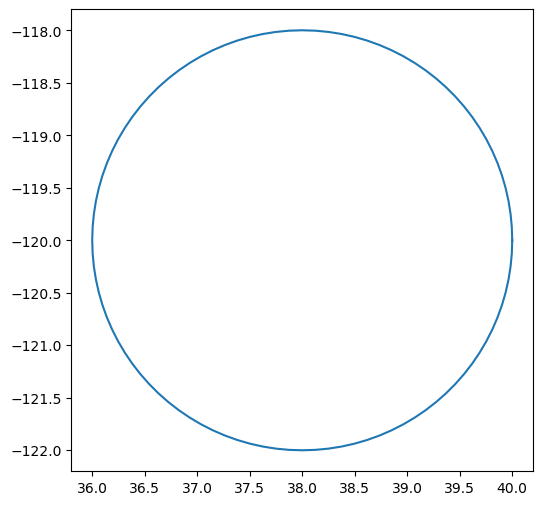

In [6]:

def regular_polygon(cx, cy, radius, n_sides):
    angles = np.linspace(0, 2 * np.pi, num=n_sides, endpoint=False)
    coords = [(cx + radius * np.cos(a), cy + radius * np.sin(a)) for a in angles]
    coords.append(coords[0])  # Ensure closure
    return Polygon(coords)

CIRCLE_RESOLUTION = 100  # Control the resolution (more sides = smoother)
CIRC_RADIUS = 2
circle = regular_polygon(history_event_y, history_event_x, CIRC_RADIUS, CIRCLE_RESOLUTION)

fig, ax = plt.subplots(figsize=(6, 6))
x_circ, y_circ = circle.exterior.xy
ax.plot(x_circ, y_circ, label="Maximum Inscribed Circle")
ax.set_aspect('equal')
plt.show()



In [7]:
# Hardcoded study-region outline (same vertices as input_data/california_shape.npy)
# Each row is [latitude, longitude].
SHAPE_COORDS = circle.exterior.xy
GRID_POINT_DENSITY_KM2 = 5e-4  # same as grid_recreations_point_process.ipynb


In [8]:
polygon = circle

lat_flat, lon_flat, grid_info = latlon_rectangular_grid_in_polygon(
    polygon, GRID_POINT_DENSITY_KM2
)
ordered_cells = get_ordered_voronoi_cells(polygon, lat_flat, lon_flat)

print(
    f"grid from density {GRID_POINT_DENSITY_KM2:.4g} pts/km²: "
    f"{grid_info['n_points']} nodes (target {grid_info['target_n']}, "
    f"spacing {grid_info['spacing_km']:.3f} km, rectangle {grid_info['grid_n_xy']})"
)
print(f"polygon area: {grid_info['area_km2']:.4g} km²")
print(f"Voronoi cells: {len(ordered_cells)}")

history_point = Point(history_event_x, history_event_y)
for j, cell in enumerate(ordered_cells):
    if cell.contains(history_point):
        print(
            f"history point ({history_event_x}, {history_event_y}) -> cell {j}, "
            f"node ({lon_flat[j]:.6f}, {lat_flat[j]:.6f})"
        )
        break


grid from density 0.0005 pts/km²: 59 nodes (target 61, spacing 44.797 km, rectangle (11, 9))
polygon area: 1.224e+05 km²
Voronoi cells: 59
history point (-120, 38) -> cell 29, node (-120.000000, 38.000000)


2026-06-19 15:19:09,599 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2026-06-19 15:19:09,600 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-19 15:19:09,600 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-19 15:19:09,600 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

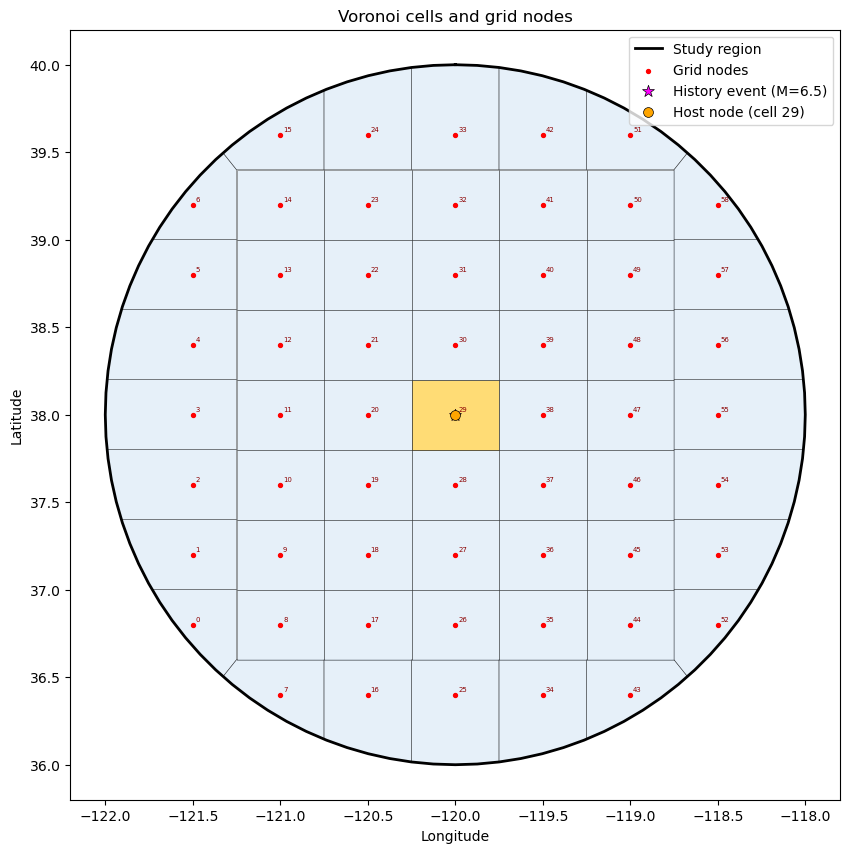

In [9]:
def _polygon_parts(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        yield geom
    elif geom.geom_type == "MultiPolygon":
        yield from geom.geoms
    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            yield from _polygon_parts(g)


history_cell_idx = None
for j, cell in enumerate(ordered_cells):
    if cell.contains(history_point):
        history_cell_idx = j
        break

fig_grid, ax = plt.subplots(figsize=(12, 10))

for j, cell in enumerate(ordered_cells):
    facecolor = "#ffd966" if j == history_cell_idx else "#d9e8f7"
    alpha = 0.9 if j == history_cell_idx else 0.65
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)  # x=lon, y=lat
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=facecolor,
                edgecolor="k",
                alpha=alpha,
                linewidth=0.4,
            )
        )

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(lon_flat, lat_flat, s=8, c="red", zorder=5, label="Grid nodes")
for j in range(len(lon_flat)):
    ax.annotate(
        str(j),
        (lon_flat[j], lat_flat[j]),
        textcoords="offset points",
        xytext=(2, 2),
        fontsize=5,
        color="darkred",
        ha="left",
        va="bottom",
        zorder=7,
    )
ax.scatter(
    [history_event_x],
    [history_event_y],
    s=80,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

if history_cell_idx is not None:
    ax.scatter(
        [lon_flat[history_cell_idx]],
        [lat_flat[history_cell_idx]],
        s=50,
        c="orange",
        edgecolors="black",
        linewidths=0.5,
        zorder=6,
        label=f"Host node (cell {history_cell_idx})",
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Voronoi cells and grid nodes")
ax.set_aspect("equal")
# ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
# ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


2026-06-19 15:19:10,237 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7f10452adcd0>
2026-06-19 15:19:10,265 - DEBUG - vmin 2.1868843572726075e-05 vmax 0.695177120630918
2026-06-19 15:19:10,266 - DEBUG - ticklocs array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])
2026-06-19 15:19:10,269 - DEBUG - vmin 2.1868843572726075e-05 vmax 0.695177120630918
2026-06-19 15:19:10,270 - DEBUG - ticklocs array([2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01])
2026

2026-06-19 15:19:13,404 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/adf/BerenisADFPro-Italic.otf', name='Berenis ADF Pro', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-06-19 15:19:13,404 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/tlwg/Umpush-Bold.ttf', name='Umpush', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-06-19 15:19:13,404 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/fonts-yrsa-rasa/Yrsa-Bold.ttf', name='Yrsa', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-06-19 15:19:13,404 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/lato/Lato-Light.ttf', name='Lato', style='normal', variant='normal', weight=300, stretch='normal', size='scalable')) = 10.145
2026-06-19 15:19:13,405 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype

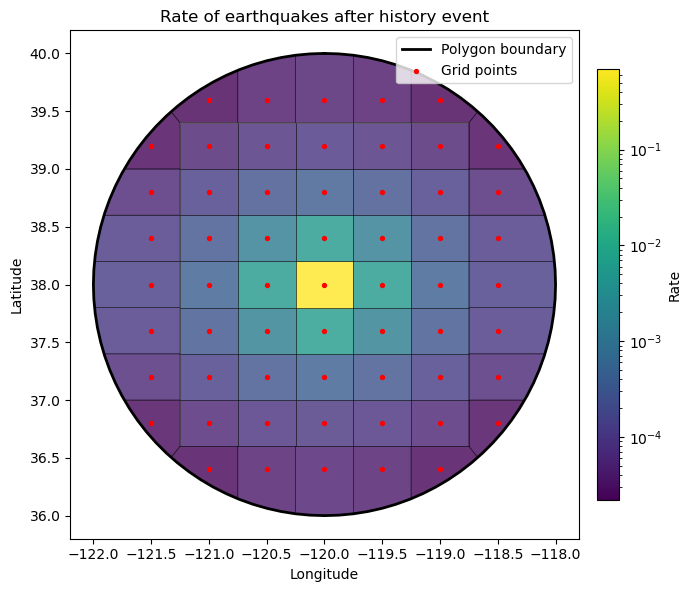

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(8, 7))
# rates = [A_h(cell, history_dict, THETA_0, A_H_RESOLUTION) for cell in ordered_cells]
rates = []
for cell in ordered_cells:
    a_h_i = A_h(cell, history_dict, THETA_0, A_H_RESOLUTION)
    rates.append(a_h_i)
norm = colors.LogNorm(vmin=np.min(rates), vmax=np.max(rates))

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame({"rate": rates}, geometry=ordered_cells)

# Plot everything in one vectorized call
gdf.plot(
    column="rate",
    ax=ax,
    cmap=plt.cm.viridis,
    norm=norm,
    edgecolor="k",
    alpha=0.8,
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "Rate", "shrink": 0.8, "pad": 0.03}
)

# Plot boundaries and scatter
poly_coords = np.asarray(polygon.exterior.coords)
ax.plot(poly_coords[:, 1], poly_coords[:, 0], color="black", linewidth=2, label="Polygon boundary")
ax.scatter(lon_flat, lat_flat, s=8, c="red", zorder=5, label="Grid points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Rate of earthquakes after history event")
ax.set_aspect("equal")
# ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
# ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


## verify integral

2026-06-19 16:54:56,635 - DEBUG - vmin 0.0001249898372344327 vmax 1.5105928068470815
2026-06-19 16:54:56,635 - DEBUG - ticklocs array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])
2026-06-19 16:54:56,645 - DEBUG - vmin 0.0001249898372344327 vmax 1.5105928068470815
2026-06-19 16:54:56,645 - DEBUG - ticklocs array([2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02])
2026-06-19 16:54:56,646 - DEBUG - vmin 0.0001249898372344327 vmax 1.5105928068470815
2026-06-19 16:54:5

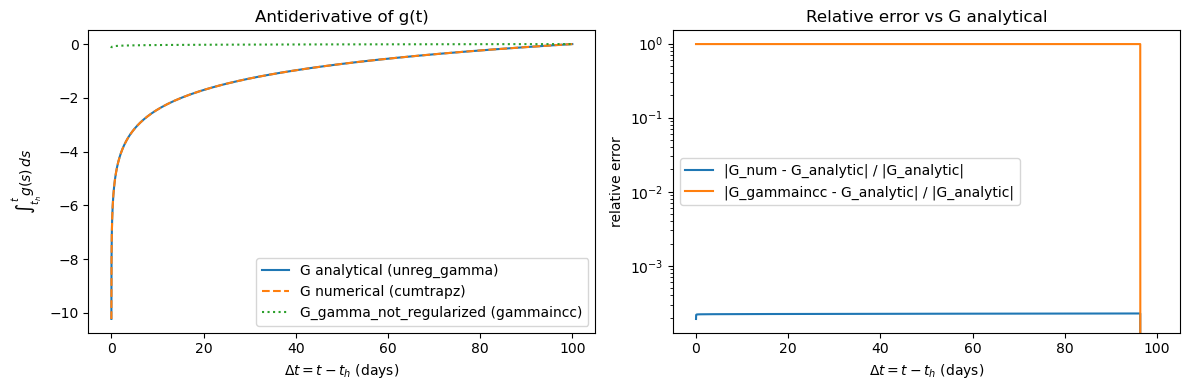

G(Δt=100 d) analytical:     0.000000
G(Δt=100 d) numerical:       0.000000
G(Δt=100 d) gammaincc:       0.000000
max rel err G_num:            2.274e-04
max rel err G_gammaincc:      9.853e-01
2026-06-19 16:54:57,165 - DEBUG - vmin 3.981071705534969e-07 vmax 251.18864315095797
2026-06-19 16:54:57,165 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01,
       1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
2026-06-19 16:54:57,179 - DEBUG - vmin 3.981071705534969e-07 vmax 251.18864315095797
2026-06-19 16:54:57,179 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
      

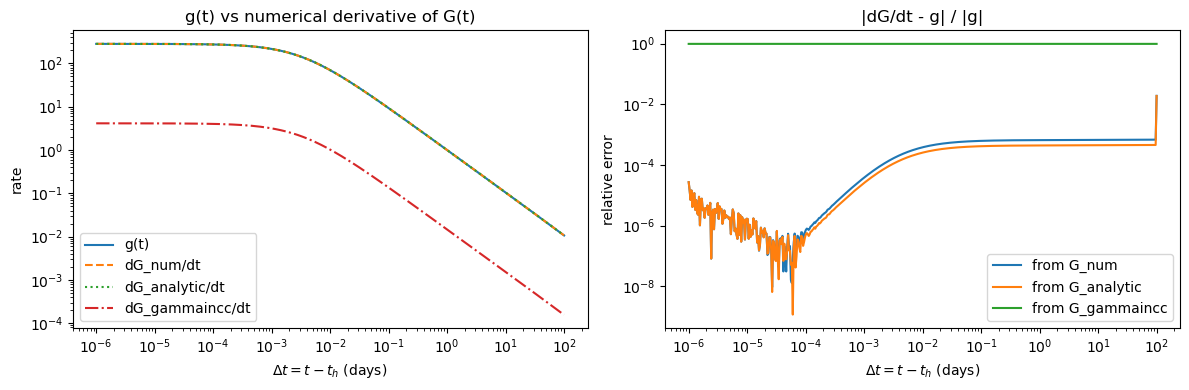

max |dG_num/dt - g| / |g| (Δt > 0):       1.901e-02
max |dG_analytic/dt - g| / |g| (Δt > 0):   1.878e-02
max |dG_gammaincc/dt - g| / |g| (Δt > 0): 9.853e-01


In [28]:
def G(
    t: float,
    H: History,
    params: EtasParams,
):
    return -(np.exp(params['c'] / params['tau'])/params['tau']**(params['omega'])) * unreg_gamma(-params['omega'], (params['c'] + t - H['t'])/params['tau'])

def G_gamma_not_regularized(
    t: float,
    H: History,
    params: EtasParams,
):
    return -(np.exp(params['c'] / params['tau'])/params['tau']**(-params['omega'])) * scipy.special.gammaincc(-params['omega'], (params['c'] + t - H['t'])/params['tau'])


# numerical integral of g(t):  ∫_{t_h}^{t} g(s) ds
# log-spaced Δt — g spikes near t_h so uniform grids are inaccurate
dt_verify = np.concatenate([[0.0], np.geomspace(1e-6, 100.0, 500)])
t_verify = dt_verify + history_dict['t']

assert np.all(np.diff(dt_verify) > 0), "dt_verify must be strictly increasing"
assert np.all(np.diff(t_verify) > 0), "t_verify must be strictly increasing"

g_vals = g(t_verify, history_dict, THETA_0)
G_num = scipy.integrate.cumulative_trapezoid(g_vals, t_verify, initial=0)
G_num -= G_num[-1]

G_analytic = G(t_verify, history_dict, THETA_0)
G_analytic -= G_analytic[-1]

G_gammaincc = G_gamma_not_regularized(t_verify, history_dict, THETA_0)
G_gammaincc -= G_gammaincc[-1]

# all y-series below share the same ascending x = dt_verify (or dt_verify[1:] on log axes)
assert len({len(dt_verify), len(g_vals), len(G_num), len(G_analytic), len(G_gammaincc)}) == 1

rel_err_num = np.abs(G_num - G_analytic) / np.maximum(np.abs(G_analytic), 1e-30)
rel_err_gammaincc = np.abs(G_gammaincc - G_analytic) / np.maximum(np.abs(G_analytic), 1e-30)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dt_verify, G_analytic, label="G analytical (unreg_gamma)")
axes[0].plot(dt_verify, G_num, "--", label="G numerical (cumtrapz)")
axes[0].plot(dt_verify, G_gammaincc, ":", label="G_gamma_not_regularized (gammaincc)")
axes[0].set_xlabel(r"$\Delta t = t - t_h$ (days)")
axes[0].set_ylabel(r"$\int_{t_h}^{t} g(s)\,ds$")
axes[0].legend()
axes[0].set_title("Antiderivative of g(t)")

dt_err = dt_verify[1:]
axes[1].semilogy(dt_err, rel_err_num[1:], label="|G_num - G_analytic| / |G_analytic|")
axes[1].semilogy(dt_err, rel_err_gammaincc[1:], label="|G_gammaincc - G_analytic| / |G_analytic|")
axes[1].set_xlabel(r"$\Delta t = t - t_h$ (days)")
axes[1].set_ylabel("relative error")
axes[1].legend()
axes[1].set_title("Relative error vs G analytical")
plt.tight_layout()
plt.show()

print(f"G(Δt=100 d) analytical:     {G_analytic[-1]:.6f}")
print(f"G(Δt=100 d) numerical:       {G_num[-1]:.6f}")
print(f"G(Δt=100 d) gammaincc:       {G_gammaincc[-1]:.6f}")
print(f"max rel err G_num:            {rel_err_num[1:].max():.3e}")
print(f"max rel err G_gammaincc:      {rel_err_gammaincc[1:].max():.3e}")

# numerical derivative of G(t) vs g(t)
dG_num_dt = np.gradient(G_num, dt_verify)
dG_analytic_dt = np.gradient(G_analytic, dt_verify)
dG_gammaincc_dt = np.gradient(G_gammaincc, dt_verify)
deriv_rel_err_num = np.abs(dG_num_dt - g_vals) / np.maximum(np.abs(g_vals), 1e-30)
deriv_rel_err_analytic = np.abs(dG_analytic_dt - g_vals) / np.maximum(np.abs(g_vals), 1e-30)
deriv_rel_err_gammaincc = np.abs(dG_gammaincc_dt - g_vals) / np.maximum(np.abs(g_vals), 1e-30)

# log-scale plots need Δt > 0; keep x and y aligned via the same slice
dt_log = dt_verify[1:]
g_log = g_vals[1:]
dG_num_log = dG_num_dt[1:]
dG_analytic_log = dG_analytic_dt[1:]
dG_gammaincc_log = dG_gammaincc_dt[1:]
deriv_rel_err_num_log = deriv_rel_err_num[1:]
deriv_rel_err_analytic_log = deriv_rel_err_analytic[1:]
deriv_rel_err_gammaincc_log = deriv_rel_err_gammaincc[1:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dt_log, g_log, label="g(t)")
axes[0].plot(dt_log, dG_num_log, "--", label="dG_num/dt")
axes[0].plot(dt_log, dG_analytic_log, ":", label="dG_analytic/dt")
axes[0].plot(dt_log, dG_gammaincc_log, "-.", label="dG_gammaincc/dt")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\Delta t = t - t_h$ (days)")
axes[0].set_ylabel("rate")
axes[0].legend()
axes[0].set_title("g(t) vs numerical derivative of G(t)")

axes[1].semilogy(dt_log, deriv_rel_err_num_log, label="from G_num")
axes[1].semilogy(dt_log, deriv_rel_err_analytic_log, label="from G_analytic")
axes[1].semilogy(dt_log, deriv_rel_err_gammaincc_log, label="from G_gammaincc")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\Delta t = t - t_h$ (days)")
axes[1].set_ylabel("relative error")
axes[1].set_title("|dG/dt - g| / |g|")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"max |dG_num/dt - g| / |g| (Δt > 0):       {deriv_rel_err_num_log.max():.3e}")
print(f"max |dG_analytic/dt - g| / |g| (Δt > 0):   {deriv_rel_err_analytic_log.max():.3e}")
print(f"max |dG_gammaincc/dt - g| / |g| (Δt > 0): {deriv_rel_err_gammaincc_log.max():.3e}")


In [29]:
G_analytic


array([-10.22768329, -10.2274015 , -10.2273909 , -10.22737991,
       -10.2273685 , -10.22735666, -10.22734438, -10.22733164,
       -10.22731842, -10.2273047 , -10.22729047, -10.2272757 ,
       -10.22726038, -10.22724448, -10.22722798, -10.22721086,
       -10.2271931 , -10.22717467, -10.22715555, -10.22713571,
       -10.22711513, -10.22709377, -10.22707161, -10.22704861,
       -10.22702475, -10.227     , -10.22697431, -10.22694766,
       -10.22692001, -10.22689132, -10.22686155, -10.22683066,
       -10.22679862, -10.22676537, -10.22673087, -10.22669507,
       -10.22665793, -10.22661939, -10.22657941, -10.22653792,
       -10.22649488, -10.22645022, -10.22640388, -10.2263558 ,
       -10.22630592, -10.22625417, -10.22620047, -10.22614475,
       -10.22608695, -10.22602697, -10.22596475, -10.22590018,
       -10.2258332 , -10.2257637 , -10.22569159, -10.22561678,
       -10.22553916, -10.22545863, -10.22537507, -10.22528839,
       -10.22519845, -10.22510514, -10.22500833, -10.22

In [30]:
G_gammaincc


array([-0.14985781, -0.14985369, -0.14985353, -0.14985337, -0.1498532 ,
       -0.14985303, -0.14985285, -0.14985266, -0.14985247, -0.14985227,
       -0.14985206, -0.14985184, -0.14985162, -0.14985139, -0.14985114,
       -0.14985089, -0.14985063, -0.14985036, -0.14985008, -0.14984979,
       -0.14984949, -0.14984918, -0.14984885, -0.14984852, -0.14984817,
       -0.1498478 , -0.14984743, -0.14984704, -0.14984663, -0.14984621,
       -0.14984577, -0.14984532, -0.14984485, -0.14984436, -0.14984386,
       -0.14984333, -0.14984279, -0.14984223, -0.14984164, -0.14984103,
       -0.1498404 , -0.14983975, -0.14983907, -0.14983836, -0.14983763,
       -0.14983687, -0.14983609, -0.14983527, -0.14983442, -0.14983355,
       -0.14983263, -0.14983169, -0.14983071, -0.14982969, -0.14982863,
       -0.14982754, -0.1498264 , -0.14982522, -0.14982399, -0.14982272,
       -0.14982141, -0.14982004, -0.14981862, -0.14981715, -0.14981562,
       -0.14981404, -0.14981239, -0.14981069, -0.14980892, -0.14

## time to next event


In [102]:
t_prime_vec = np.linspace(0, 100, 300) + history_dict['t']

second_gamma = unreg_gamma(-THETA_0['omega'], THETA_0['c'] / THETA_0['tau'])

def log_rhs(t_prime: float, t: float, target_polygon: Polygon, H: History, params: EtasParams, resolution: int = 50):
    """
    Computes the log-space right-hand side for numerical stability.
    """
    t_h = H['t']
    
    # Linear background term
    term1 = -polygon_area(target_polygon) * params['mu'] * (t_prime - t)
    
    # Non-linear triggering term
    gamma_diff = (
        unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) - 
        unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
    )
    
    const_multiplier = np.exp(params['c'] / params['tau']) / (params['tau']**(params['omega']))
    term2 = A_h(target_polygon, H, params, resolution) * const_multiplier * gamma_diff
    
    return term1 + term2

def log_rhs_region(t_prime: float, t: float, H: History, params: EtasParams, resolution: int = 50):
    """
    Computes the log-space right-hand side for numerical stability.
    """
    t_h = H['t']
    
    # Linear background term
    term1 = -np.pi * CIRC_RADIUS**2 * params['mu'] * (t_prime - t)
    
    # Non-linear triggering term
    gamma_diff = (
        unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) - 
        unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
    )
    
    const_multiplier = np.exp(params['c'] / params['tau']) / (params['tau']**(params['omega']))
    term2 = A_h_of_m_circ(H['m'], params, R=CIRC_RADIUS) * const_multiplier * gamma_diff
    
    return term1 + term2

all_P_vecs = []
for cell in ordered_cells:
    rhs_vec = np.exp(log_rhs(t_prime_vec, history_dict['t'], cell, history_dict, THETA_0, A_H_RESOLUTION))
    all_P_vecs.append(rhs_vec)





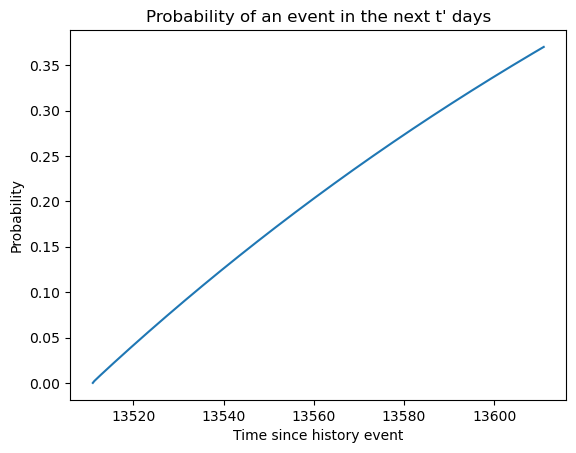

In [103]:
f, ax = plt.subplots()
ax.plot(t_prime_vec, 1 - all_P_vecs[3])
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


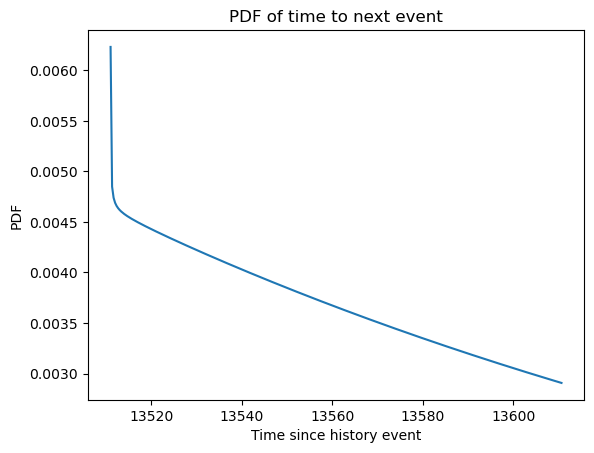

In [104]:
# pdf
pdf = np.diff(1 - all_P_vecs[3]) / np.diff(t_prime_vec)

f, ax = plt.subplots()
ax.plot(t_prime_vec[:-1], pdf)
ax.set_xlabel("Time since history event")
ax.set_ylabel("PDF")
ax.set_title("PDF of time to next event")
plt.show()


In [105]:
t_prime_vec = np.linspace(0, 100, 300) + history_dict['t']

second_gamma = unreg_gamma(-THETA_0['omega'], THETA_0['c'] / THETA_0['tau'])


# Raw SHAPE_COORDS polygon is (lat, lon); swap to (lon, lat) for A_h / history_dict.
california_lonlat = transform(_swap_xy, polygon)

P_vec_california = np.exp(
    log_rhs(t_prime_vec, history_dict['t'], california_lonlat, history_dict, THETA_0, A_H_RESOLUTION)
)


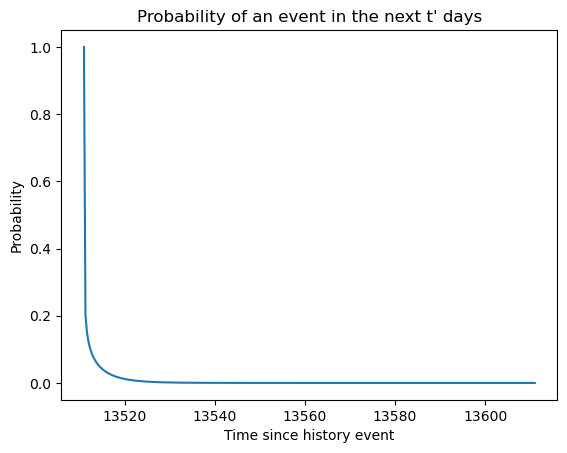

In [106]:
f, ax = plt.subplots()
ax.plot(t_prime_vec, P_vec_california)
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


### prob next event entire region

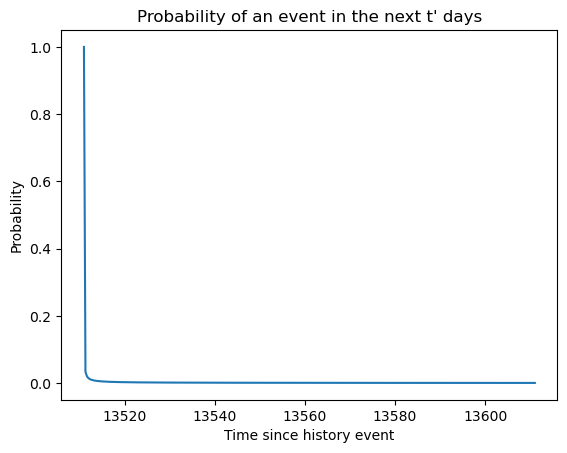

In [107]:
P_vec_california = np.exp(
    log_rhs_region(t_prime_vec, history_dict['t'], history_dict, THETA_0, resolution=A_H_RESOLUTION)
)

f, ax = plt.subplots()
ax.plot(t_prime_vec, P_vec_california)
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


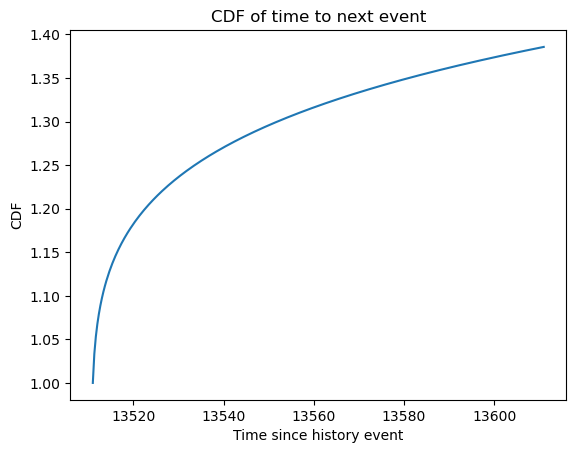

In [108]:
# cdf circ analytical
cdf_circ_analytical = np.cumsum(P_vec_california)
f, ax = plt.subplots()
ax.plot(t_prime_vec, cdf_circ_analytical)
ax.set_xlabel("Time since history event")
ax.set_ylabel("CDF")
ax.set_title("CDF of time to next event")
plt.show()


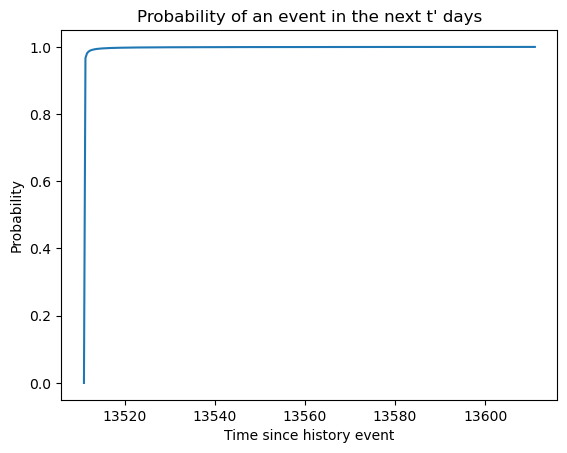

In [109]:
# Probability of NO event
S_vec_california = np.exp(
    log_rhs_region(t_prime_vec, history_dict['t'], history_dict, THETA_0, resolution=A_H_RESOLUTION)
)

# Probability of AN event (CDF)
P_vec_california = 1 - S_vec_california

f, ax = plt.subplots()
ax.plot(t_prime_vec, P_vec_california)
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


## Catalog continuation forecast

Run classic ETAS catalog continuation (`simulate_catalog_continuation`) from forecast start time **T**, using only the single history event above as auxiliary catalog. Each recreation keeps the **first forecast event** after **T** (extending the forecast window if needed).

In [110]:
# --- forecast settings (edit these) ---
FORECAST_START = history_event_time  # time T: forecast window starts here
N_RECREATIONS = 1000
N_FORECAST_EVENTS = 1  # keep the first event after T in each recreation
SEED_START = 0

# initial forecast window; extended automatically until N_FORECAST_EVENTS are found
INITIAL_FORECAST_DAYS = 30
MAX_FORECAST_DAYS = 3650
FORECAST_GROWTH_FACTOR = 2.0

# magnitude distribution (Gutenberg–Richter b=1 => beta = ln(10))
BETA_MAIN = np.log(10)
MC = THETA_0["m_c"]

from pathlib import Path
from typing import Optional

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history_circular_domain"

# --- persistence ---
# Load only when the canonical CSV for current settings exists (n, seed, resolution, …).
# Older files with different tags are ignored; set FORCE_RECREATE_RECREATIONS = True to always re-simulate.
FORCE_RECREATE_RECREATIONS = False
SAVE_RECREATIONS_OUTPUT = True

# Optional explicit paths (str or Path); None = use canonical name under RECREATIONS_OUTPUT_DIR
SAVED_FORECAST_RECREATIONS_PATH = None
SAVED_GRID_RECREATIONS_PATH = None


def forecast_recreations_path(n_recreations=None, seed_start=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    seed = SEED_START if seed_start is None else int(seed_start)
    return RECREATIONS_OUTPUT_DIR / f"forecast_recreations_n{n}_seed{seed}.csv"


def grid_recreations_path(n_recreations=None, resolution=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    res = A_H_RESOLUTION if resolution is None else int(resolution)
    return RECREATIONS_OUTPUT_DIR / f"grid_recreations_n{n}_res{res}.csv"


# Backward compat for kernels that still reference the old helper name.
grid_recreations_epsilon_path = grid_recreations_path


def _resolve_saved_csv(explicit_path, canonical_path: Path) -> Optional[Path]:
    """Load only when the file matches current settings (canonical name encodes parameters)."""
    if explicit_path is not None:
        path = Path(explicit_path)
        if not path.is_file():
            raise FileNotFoundError(f"Saved recreations not found: {path}")
        if path.resolve() != canonical_path.resolve():
            print(
                f"Explicit path {path.name} does not match current settings "
                f"({canonical_path.name}); re-simulating."
            )
            return None
        return path
    if canonical_path.is_file():
        return canonical_path
    return None


def _note_stale_saved_csvs(glob_pattern: str, canonical_path: Path) -> None:
    """Hint when older CSVs exist but none match the current parameter tag."""
    if not RECREATIONS_OUTPUT_DIR.is_dir():
        return
    stale = sorted(
        RECREATIONS_OUTPUT_DIR.glob(glob_pattern),
        key=lambda p: p.name,
    )
    stale = [p for p in stale if p.resolve() != canonical_path.resolve()]
    if stale:
        names = ", ".join(p.name for p in stale[:5])
        suffix = " ..." if len(stale) > 5 else ""
        print(
            f"Note: found {len(stale)} saved CSV(s) with other parameters "
            f"({names}{suffix}); need {canonical_path.name} for current settings."
        )




In [111]:
# ETAS parameters in the log10 form expected by simulate_catalog_continuation
theta = {
    key: THETA_0[key]
    for key in [
        "log10_mu",
        "log10_k0",
        "a",
        "log10_c",
        "omega",
        "log10_tau",
        "log10_d",
        "gamma",
        "rho",
    ]
}


def _to_naive_utc(ts):
    t = pd.to_datetime(ts, utc=True)
    return t.tz_convert(None)


def simulate_single_event_recreations(
    auxiliary_catalog,
    *,
    auxiliary_start,
    forecast_start,
    polygon,
    theta,
    mc,
    beta_main,
    n_events,
    n_recreations,
    seed_start,
    initial_forecast_days=30,
    max_forecast_days=3650,
    growth_factor=2.0,
):
    """Call simulate_catalog_continuation; keep first n_events after forecast_start."""
    aux_start = _to_naive_utc(auxiliary_start)
    f_start = _to_naive_utc(forecast_start)

    aux = auxiliary_catalog.copy()
    aux["time"] = pd.to_datetime(aux["time"], utc=True).dt.tz_convert(None)

    records = []
    seeds = range(seed_start, seed_start + n_recreations)
    for i, seed in enumerate(
        tqdm(seeds, total=n_recreations, desc="Recreations", unit="run")
    ):
        np.random.seed(int(seed))

        forecast_days = float(initial_forecast_days)
        chosen = None
        while forecast_days <= float(max_forecast_days):
            sim_end = f_start + dt.timedelta(days=forecast_days)

            cont = simulation.simulate_catalog_continuation(
                auxiliary_catalog=aux,
                auxiliary_start=aux_start,
                auxiliary_end=f_start,
                polygon=polygon,
                simulation_end=sim_end,
                parameters=dict(theta),
                mc=float(mc),
                beta_main=beta_main,
                filter_polygon=False,
                magnitude_generator=mc_b_est.simulate_magnitudes,
            )

            cont = cont.copy()
            cont["time"] = pd.to_datetime(cont["time"], utc=True).dt.tz_convert(None)

            forecast_events = cont.loc[cont["time"] > f_start].sort_values("time")
            forecast_events = forecast_events.head(int(n_events))

            if len(forecast_events) >= int(n_events):
                chosen = forecast_events
                break

            forecast_days *= float(growth_factor)

        if chosen is None:
            raise RuntimeError(
                f"Recreation {i} (seed={seed}) did not reach {n_events} event(s) "
                f"within {max_forecast_days} forecast days."
            )

        chosen = chosen[["time", "latitude", "longitude", "magnitude"]].copy()
        chosen["recreation"] = i
        chosen["seed"] = int(seed)
        chosen["event_idx"] = np.arange(len(chosen), dtype=int)
        records.append(chosen)

    if not records:
        return pd.DataFrame(
            columns=[
                "time",
                "latitude",
                "longitude",
                "magnitude",
                "recreation",
                "seed",
                "event_idx",
            ]
        )
    return pd.concat(records, ignore_index=True)


auxiliary_catalog = pd.DataFrame(
    {
        "time": [_to_naive_utc(history_event_time)],
        "latitude": [history_event_y],
        "longitude": [history_event_x],
        "magnitude": [history_event_magnitude],
        "xi_plus_1": [1.0],
    }
)
auxiliary_start = auxiliary_catalog["time"].min()
forecast_start = _to_naive_utc(FORECAST_START)

_forecast_canonical = forecast_recreations_path()
_forecast_load_path = None if FORCE_RECREATE_RECREATIONS else _resolve_saved_csv(
    SAVED_FORECAST_RECREATIONS_PATH,
    _forecast_canonical,
)

_forecast_loaded = False

if not FORCE_RECREATE_RECREATIONS and _forecast_load_path is not None:
    _candidate = pd.read_csv(_forecast_load_path, parse_dates=["time"])
    n_rec_ok = _candidate["recreation"].nunique() == N_RECREATIONS
    n_evt_ok = (
        _candidate.groupby("recreation")["event_idx"].max().add(1) >= N_FORECAST_EVENTS
    ).all()
    if n_rec_ok and n_evt_ok:
        print(f"Loading forecast_recreations from {_forecast_load_path}")
        forecast_recreations = _candidate
        _forecast_loaded = True
    else:
        print(
            f"Saved forecast_recreations shape does not match "
            f"n={N_RECREATIONS}, events={N_FORECAST_EVENTS}; re-simulating."
        )

if not _forecast_loaded:
    if FORCE_RECREATE_RECREATIONS:
        print("FORCE_RECREATE_RECREATIONS=True: simulating classic ETAS recreations...")
    else:
        _note_stale_saved_csvs(
            "forecast_recreations_n*_seed*.csv",
            _forecast_canonical,
        )
        if _forecast_load_path is None:
            print(
                f"No saved forecast_recreations for current settings "
                f"({_forecast_canonical.name}); simulating..."
            )
    forecast_recreations = simulate_single_event_recreations(
        auxiliary_catalog,
        auxiliary_start=auxiliary_start,
        forecast_start=forecast_start,
        polygon=polygon,
        theta=theta,
        mc=MC,
        beta_main=BETA_MAIN,
        n_events=N_FORECAST_EVENTS,
        n_recreations=N_RECREATIONS,
        seed_start=SEED_START,
        initial_forecast_days=INITIAL_FORECAST_DAYS,
        max_forecast_days=MAX_FORECAST_DAYS,
        growth_factor=FORECAST_GROWTH_FACTOR,
    )

print(
    f"Forecast from T={forecast_start}: "
    f"{len(forecast_recreations)} event(s) "
    f"({forecast_recreations['recreation'].nunique()} recreations x {N_FORECAST_EVENTS})"
)

if SAVE_RECREATIONS_OUTPUT and not _forecast_loaded:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    forecast_recreations.to_csv(_forecast_canonical, index=False)
    print(f"Saved forecast_recreations -> {_forecast_canonical}")

forecast_recreations



Loading forecast_recreations from /home/neriberman/Repos/etas/outputs/single_point_history_circular_domain/forecast_recreations_n1000_seed0.csv
Forecast from T=2006-12-29 00:00:00: 1000 event(s) (1000 recreations x 1)


,time,latitude,longitude,magnitude,recreation,seed,event_idx
0,2006-12-29 01:55:59.861478953,37.986817,-119.934974,3.745207,0,0,0
1,2006-12-29 00:01:27.132085344,37.987603,-120.032806,3.568913,1,1,0
2,2006-12-29 00:45:52.260989313,38.041409,-120.071521,5.031362,2,2,0
3,2006-12-29 00:07:54.118165641,38.006029,-119.978155,3.763826,3,3,0
4,2006-12-29 00:06:29.294487538,37.999117,-119.995402,4.085101,4,4,0
...,...,...,...,...,...,...,...
995,2006-12-29 00:00:23.412718509,37.904112,-120.116990,4.565290,995,995,0
996,2006-12-29 00:02:42.066723972,37.971916,-119.932256,4.575856,996,996,0
997,2006-12-29 00:01:41.311530831,38.039972,-120.046302,3.765985,997,997,0
998,2006-12-29 00:09:09.917280360,37.977311,-119.939208,3.795307,998,998,0


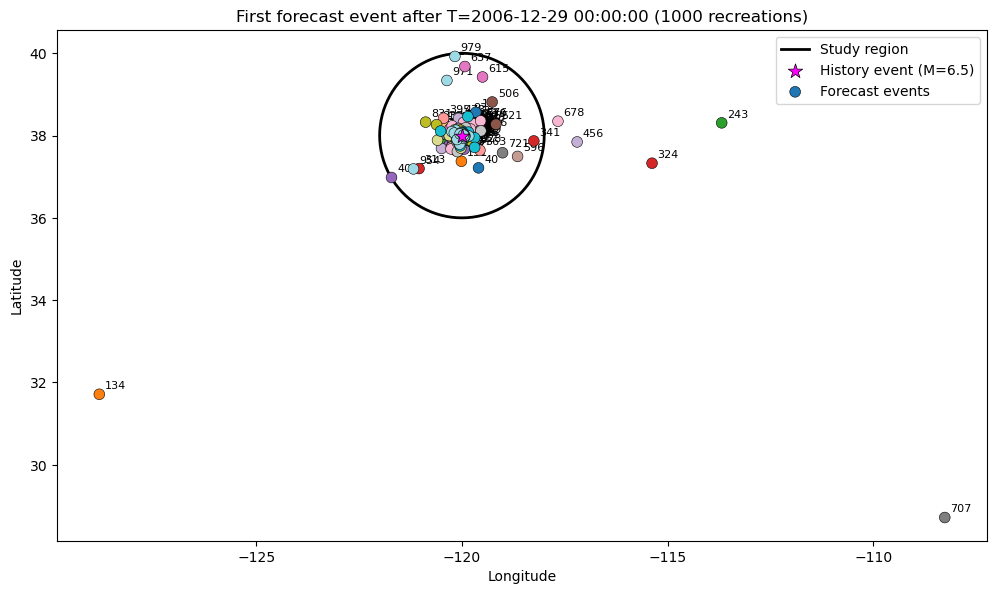

In [112]:
fig_forecast, ax = plt.subplots(figsize=(12, 10))

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

ax.scatter(
    forecast_recreations["longitude"],
    forecast_recreations["latitude"],
    s=60,
    c=forecast_recreations["recreation"],
    cmap="tab20",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    label="Forecast events",
)

for _, row in forecast_recreations.iterrows():
    ax.annotate(
        str(int(row["recreation"])),
        (row["longitude"], row["latitude"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"First forecast event after T={FORECAST_START} ({N_RECREATIONS} recreations)")
ax.set_aspect("equal")
# ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
# ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


Binned 1000 simulated event(s) from 1000 recreations over 30 day forecast window.
Non-zero cells: 22 / 59; max count in one cell: 936
2026-06-19 23:30:35,902 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7f103b6100d0>
2026-06-19 23:30:35,973 - DEBUG - vmin 3.437542808103896e-07 vmax 0.00048004601947378286
2026-06-19 23:30:35,974 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02])
2026-06-19 23:30:35,982 - DEBUG - vmin 3.437542808103896e-07 vmax 0.00048004601947378286
2026-06-19 23:30:35,982 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02

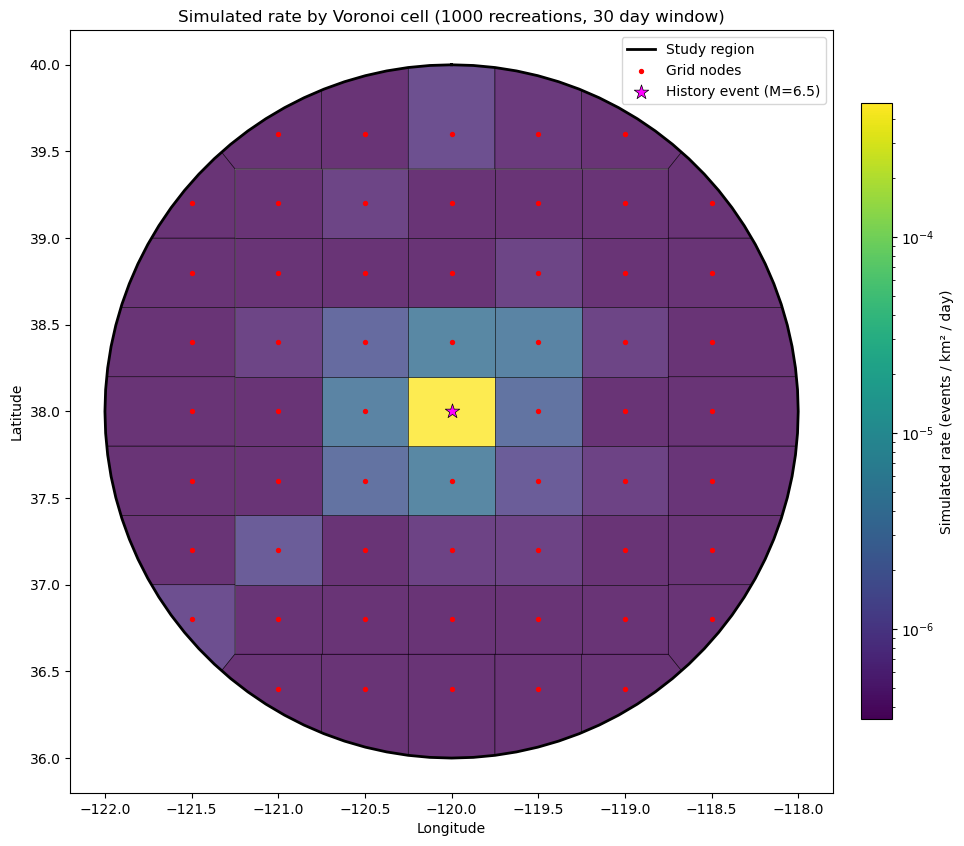

In [113]:
# Empirical rate per Voronoi cell from catalog-continuation recreations


def _polygon_parts(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        yield geom
    elif geom.geom_type == "MultiPolygon":
        yield from geom.geoms
    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            yield from _polygon_parts(g)


def calculate_areas_km2(polygons):
    geod = pyproj.Geod(ellps="WGS84")
    areas = []
    for poly in polygons:
        if poly.is_empty:
            areas.append(0.0)
        else:
            area_m2, _ = geod.geometry_area_perimeter(poly)
            areas.append(abs(area_m2) / 1e6)
    return areas


sim_events = (
    forecast_recreations.sort_values(["recreation", "time"])
    .groupby("recreation", as_index=False)
    .head(N_FORECAST_EVENTS)
)

counts_per_cell = np.zeros(len(ordered_cells), dtype=int)
for lon, lat in zip(sim_events["longitude"].to_numpy(), sim_events["latitude"].to_numpy()):
    p = Point(lon, lat)
    for j, cell in enumerate(ordered_cells):
        if cell.contains(p):
            counts_per_cell[j] += 1
            break

cell_areas_km2 = np.array(calculate_areas_km2(ordered_cells), dtype=float)
forecast_days = float(INITIAL_FORECAST_DAYS)
n_realizations = int(sim_events["recreation"].nunique())

# events / km² / day
sim_rate_per_cell = np.zeros(len(ordered_cells), dtype=float)
valid = cell_areas_km2 > 0
sim_rate_per_cell[valid] = counts_per_cell[valid] / (
    # n_realizations * forecast_days * cell_areas_km2[valid]
    n_realizations * cell_areas_km2[valid]
)

print(
    f"Binned {len(sim_events)} simulated event(s) from {n_realizations} recreations "
    f"over {forecast_days:.0f} day forecast window."
)
print(
    f"Non-zero cells: {(counts_per_cell > 0).sum()} / {len(ordered_cells)}; "
    f"max count in one cell: {counts_per_cell.max()}"
)

fig_sim_rate, ax = plt.subplots(figsize=(12, 10))
positive_rates = sim_rate_per_cell[sim_rate_per_cell > 0]
rate_vmin = float(positive_rates.min()) if positive_rates.size else 1e-20
rate_vmax = float(max(sim_rate_per_cell.max(), rate_vmin * 10))
plot_rate = np.maximum(sim_rate_per_cell, rate_vmin)
norm = colors.LogNorm(vmin=rate_vmin, vmax=rate_vmax)
cmap = plt.cm.viridis

for j, cell in enumerate(ordered_cells):
    color = cmap(norm(plot_rate[j]))
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=color,
                edgecolor="k",
                alpha=0.8,
                linewidth=0.4,
            )
        )

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")
ax.scatter(lon_flat, lat_flat, s=8, c="red", zorder=5, label="Grid nodes")
ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label("Simulated rate (events / km² / day)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Simulated rate by Voronoi cell "
    f"({n_realizations} recreations, {forecast_days:.0f} day window)"
)
ax.set_aspect("equal")
# ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
# ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


Recreations: 1000, first events (event_idx=0): 1000
Time to first event (days): median=0.006, 5-95%=0.000-0.322
2026-06-19 23:30:36,316 - DEBUG - vmin 1.8252919508047797e-06 vmax 14.185414967648532
2026-06-19 23:30:36,317 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02, 1.e+03])
2026-06-19 23:30:36,329 - DEBUG - vmin 1.8252919508047797e-06 vmax 14.185414967648532
2026-06-19 23:30:36,329 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00,

2026-06-19 23:30:36,431 - DEBUG - vmin 1.8252919508047797e-06 vmax 14.185414967648532
2026-06-19 23:30:36,432 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02, 1.e+03])
2026-06-19 23:30:36,433 - DEBUG - vmin 1.8252919508047797e-06 vmax 14.185414967648532
2026-06-19 23:30:36,433 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,


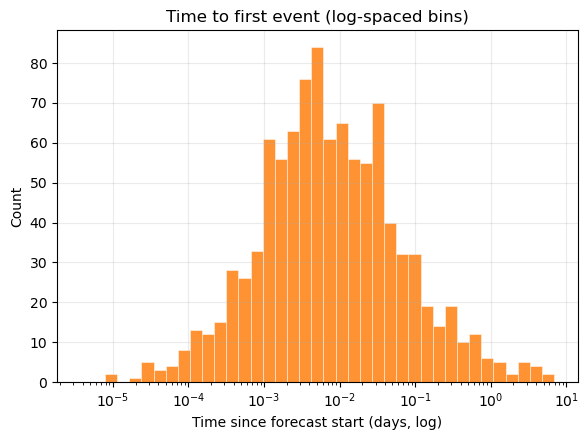

count    1000.000000
mean        0.094529
std         0.441218
min         0.000004
25%         0.001778
50%         0.006429
75%         0.030749
max         6.828349
dtype: float64

In [114]:
# Time to first forecast event — same style as grid_recreations_point_process.ipynb Step 5
FIRST_EVENT_IDX = 0
SECONDS_PER_DAY = 86400.0

t0 = pd.to_datetime(FORECAST_START, utc=True)

df_rec = forecast_recreations.loc[
    forecast_recreations["event_idx"] == FIRST_EVENT_IDX
].copy()
df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
df_rec = df_rec.sort_values(["recreation", "time"]).reset_index(drop=True)
df_rec["t_from_start_days"] = (df_rec["time"] - t0).dt.total_seconds() / SECONDS_PER_DAY

dt_to_first = df_rec.loc[df_rec["t_from_start_days"] > 0, "t_from_start_days"].to_numpy()

print(
    f"Recreations: {df_rec['recreation'].nunique()}, "
    f"first events (event_idx={FIRST_EVENT_IDX}): {len(df_rec)}"
)
if np.any(dt_to_first > 0):
    q = np.quantile(dt_to_first, [0.05, 0.5, 0.95])
    print(f"Time to first event (days): median={q[1]:.3f}, 5-95%={q[0]:.3f}-{q[2]:.3f}")

fig_delta_t, ax = plt.subplots(figsize=(6, 4.5))
if len(dt_to_first):
    bins_dt = np.logspace(
        np.log10(dt_to_first.min()),
        np.log10(dt_to_first.max() * 1.01),
        40,
    )
    ax.hist(
        dt_to_first,
        bins=bins_dt,
        color="tab:orange",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_xscale("log")
ax.set_xlabel("Time since forecast start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Time to first event (log-spaced bins)")
ax.grid(True, alpha=0.25)

fig_delta_t.tight_layout()
plt.show()

pd.Series(dt_to_first).describe()


Text(0.5, 1.0, 'CDF of time to first event')

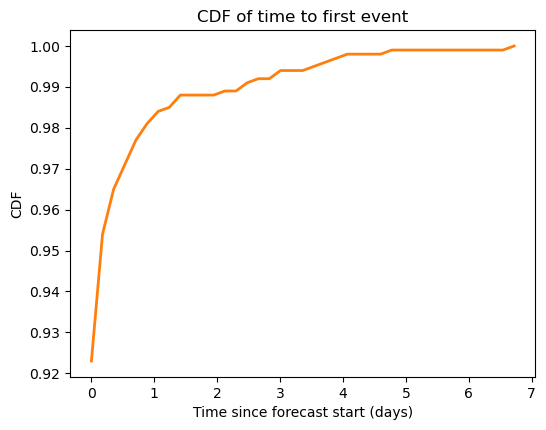

In [115]:
bins_dt = np.linspace(
        dt_to_first.min(),
        dt_to_first.max() * 1.01,
        40,
    )
    
hist, bins = np.histogram(
    dt_to_first,
    bins=bins_dt,
)

# CDF
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

fig_cdf, ax_cdf = plt.subplots(figsize=(6, 4.5))
ax_cdf.plot(bins[:-1], cdf, color="tab:orange", linewidth=2)
ax_cdf.set_xlabel("Time since forecast start (days)")
ax_cdf.set_ylabel("CDF")
ax_cdf.set_title("CDF of time to first event")


### Analytical solution for curcular region

In [116]:
spatial_comp = lambda r, rho, gamma, m_h, m_c, d: 1/ (r**2 + d*np.exp(gamma*(m_h - m_c)))**rho

# def A_h_circ(
#     R,
#     rho,
#     gamma,
#     m_h,
#     m_c,
#     d,
#     K,
#     alpha,
#     ):
#     return K * np.pi * np.exp(alpha * (m_h - m_c)) * (spatial_comp(R, rho, gamma, m_h, m_c, d) - spatial_comp(0, rho, gamma, m_h, m_c, d))

def A_h_circ(
    R,
    m_h,
    params,
):
    return (
        (params['k0'] * np.pi * np.exp(params['a'] * (m_h - params['m_c'])) / params['rho'])
        * (
            spatial_comp(0, params['rho'], params['gamma'], m_h, params['m_c'], params['d'])
            - spatial_comp(R, params['rho'], params['gamma'], m_h, params['m_c'], params['d'])
        )
    )


S = lambda r: np.pi * r**2

def background(t_prime, params):
    return - params['mu'] * S(CIRC_RADIUS) * t_prime

def K(params):
    return np.exp(params["c"]/params["tau"]) / params['tau']**(params['omega'])


def log_t_next(t_prime, H, params):
    "When t = t_h"
    return (
        background(t_prime, params)
        + (
            A_h_circ(CIRC_RADIUS, H['m'], params) * K(params)
            * (
                unreg_gamma(-params['omega'], (params['c'] + t_prime) / params['tau'])
                - unreg_gamma(-params['omega'], params['c'] / params['tau']))
        )
    )


Text(0.5, 1.0, "Probability of no event before t'")

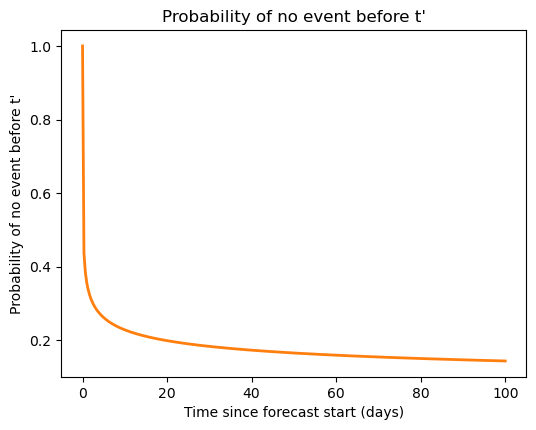

In [117]:
t_prime_vec = np.linspace(0, 100, 300)
P_no_event_before_t_prime = np.exp(log_t_next(t_prime_vec, history_dict, THETA_0))

fig_P_no_event_before_t_prime, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_vec, P_no_event_before_t_prime, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("Probability of no event before t'")
ax.set_title("Probability of no event before t'")


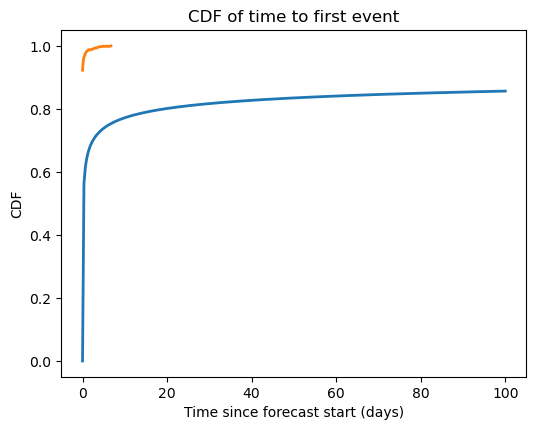

In [118]:
# CDF
cdf = 1 - P_no_event_before_t_prime
ax_cdf.plot(t_prime_vec, cdf, color="tab:blue", linewidth=2)
ax_cdf.set_xlabel("Time since forecast start (days)")
ax_cdf.set_ylabel("CDF")
ax_cdf.set_title("CDF of time to first event")
fig_cdf


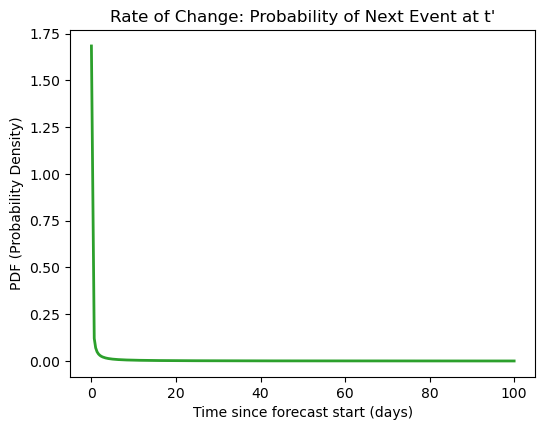

In [119]:
# Compute the spacing between time steps
dt = t_prime_vec[1] - t_prime_vec[0]

# Calculate the PDF as the numerical derivative of the CDF
pdf = np.gradient(cdf, dt)

# Plotting the PDF
fig_pdf, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_vec, pdf, color="tab:green", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("PDF (Probability Density)")
ax.set_title("Rate of Change: Probability of Next Event at t'")
plt.show()


# Simulate times on the grid

In [120]:
# def rhs(t_prime, t, H, params):
#     t_h = H['t']
#     rhs = np.exp(-params['mu'] * (t_prime - t)) * np.exp(
#         A_h(H['x'], H['y'], H, params) * (
#             np.exp(params["c"]/params["tau"]) / params['tau']**(-params['omega'])
#             ) * (
#                 unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) -
#                 unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
#                 )
#         )
#     return rhs

def solve_next_event_time_per_cell(U: float, t: float, target_polygon: Polygon, H: History, params: EtasParams, resolution: int = 50):
    """
    Solves for t_prime using the log-space RHS and Brent's method.
    """
    target_val = np.log(U)
    
    def residual(t_prime):
        return log_rhs(t_prime, t, target_polygon, H, params, resolution) - target_val

    # Dynamic bracketing
    upper_bound = t + 1.0
    while residual(upper_bound) > 0:
        upper_bound = t + (upper_bound - t) * 2.0
        
    sol = root_scalar(residual, bracket=[t, upper_bound], method='brentq')
    return sol.root 


In [121]:
## create a single realization of the point process
def create_single_realization(
    rng: np.random.RandomState,
    history_dict: History,
    ordered_cells: list[Polygon],
    lon_flat: np.ndarray,
    lat_flat: np.ndarray,
    resolution: int = 50,
) -> dict:
    ordered_event_times = []
    for cell in ordered_cells:
        U = rng.uniform()
        t_prime = solve_next_event_time_per_cell(
            U, history_dict["t"], cell, history_dict, THETA_0, resolution
        )
        ordered_event_times.append(t_prime)

    min_index = int(np.argmin(ordered_event_times))
    min_event_time = ordered_event_times[min_index]
    magnitude = mc_b_est.simulate_magnitudes(1, BETA_MAIN, MC)[0]

    return {
        "time": min_event_time,
        "magnitude": magnitude,
        "longitude": float(lon_flat[min_index]),
        "latitude": float(lat_flat[min_index]),
        "cell_idx": min_index,
    }


In [122]:
# n_recreations = N_RECREATIONS
# # n_recreations = 20
# RESOLUTION = 50
# rngseed = 1905
# recreations_df = pd.DataFrame()
# rng = np.random.RandomState(rngseed)
# for i in tqdm(range(n_recreations)):
#     # U = rng.uniform()
#     event_dict = create_single_realization(rng, history_dict, ordered_cells, lon_flat, lat_flat, RESOLUTION)
#     recreations_df = pd.concat([recreations_df, pd.DataFrame([event_dict])], ignore_index=True)
#     rngseed += 1
#     rng = np.random.RandomState(rngseed)
# recreations_df


In [123]:
if "grid_recreations_path" not in globals():
    from pathlib import Path
    from typing import Optional

    if "RECREATIONS_OUTPUT_DIR" not in globals():
        REPO_ROOT = Path.cwd().resolve()
        if REPO_ROOT.name == "notebooks":
            REPO_ROOT = REPO_ROOT.parent
        RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history_circular_domain"
    if "FORCE_RECREATE_RECREATIONS" not in globals():
        FORCE_RECREATE_RECREATIONS = False
    if "SAVE_RECREATIONS_OUTPUT" not in globals():
        SAVE_RECREATIONS_OUTPUT = True
    if "SAVED_GRID_RECREATIONS_PATH" not in globals():
        SAVED_GRID_RECREATIONS_PATH = None

    def grid_recreations_path(n_recreations=None, resolution=None) -> Path:
        n = N_RECREATIONS if n_recreations is None else int(n_recreations)
        res = A_H_RESOLUTION if resolution is None else int(resolution)
        return RECREATIONS_OUTPUT_DIR / f"grid_recreations_n{n}_res{res}.csv"

    def _resolve_saved_csv(explicit_path, canonical_path: Path) -> Optional[Path]:
        if explicit_path is not None:
            path = Path(explicit_path)
            if not path.is_file():
                raise FileNotFoundError(f"Saved recreations not found: {path}")
            if path.resolve() != canonical_path.resolve():
                print(
                    f"Explicit path {path.name} does not match current settings "
                    f"({canonical_path.name}); re-simulating."
                )
                return None
            return path
        if canonical_path.is_file():
            return canonical_path
        return None

    def _note_stale_saved_csvs(glob_pattern: str, canonical_path: Path) -> None:
        if not RECREATIONS_OUTPUT_DIR.is_dir():
            return
        stale = sorted(
            RECREATIONS_OUTPUT_DIR.glob(glob_pattern),
            key=lambda p: p.name,
        )
        stale = [p for p in stale if p.resolve() != canonical_path.resolve()]
        if stale:
            names = ", ".join(p.name for p in stale[:5])
            suffix = " ..." if len(stale) > 5 else ""
            print(
                f"Note: found {len(stale)} saved CSV(s) with other parameters "
                f"({names}{suffix}); need {canonical_path.name} for current settings."
            )

n_recreations = N_RECREATIONS

_grid_canonical = grid_recreations_path(n_recreations, A_H_RESOLUTION)
_grid_load_path = None if FORCE_RECREATE_RECREATIONS else _resolve_saved_csv(
    SAVED_GRID_RECREATIONS_PATH,
    _grid_canonical,
)

_grid_loaded = False

if not FORCE_RECREATE_RECREATIONS and _grid_load_path is not None:
    _candidate = pd.read_csv(_grid_load_path)
    if "epsilon" in _candidate.columns:
        _candidate = _candidate.drop(columns="epsilon")
    if len(_candidate) == n_recreations:
        print(f"Loading grid_recreations from {_grid_load_path}")
        grid_recreations = _candidate
        _grid_loaded = True
    else:
        print(
            f"Saved grid_recreations row count {len(_candidate)} "
            f"!= n_recreations={n_recreations}; re-simulating."
        )

if not _grid_loaded:
    if FORCE_RECREATE_RECREATIONS:
        print("FORCE_RECREATE_RECREATIONS=True: simulating grid point-process recreations...")
    else:
        _note_stale_saved_csvs(
            "grid_recreations_n*_res*.csv",
            _grid_canonical,
        )
        if _grid_load_path is None:
            print(
                f"No saved grid_recreations for current settings "
                f"({_grid_canonical.name}); simulating..."
            )

    rngseed = 1905
    records = []
    rng = np.random.RandomState(rngseed)

    for i in tqdm(
        range(n_recreations),
        desc="Recreations",
        unit="run",
        dynamic_ncols=True,
    ):
        event_dict = create_single_realization(
            rng,
            history_dict,
            ordered_cells,
            lon_flat,
            lat_flat,
            A_H_RESOLUTION,
        )
        records.append(event_dict)
        rngseed += 1
        rng = np.random.RandomState(rngseed)

    grid_recreations = pd.DataFrame.from_records(records)

if SAVE_RECREATIONS_OUTPUT and not _grid_loaded:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    grid_recreations.to_csv(_grid_canonical, index=False)
    print(f"Saved grid_recreations -> {_grid_canonical}")

grid_recreations



Loading grid_recreations from /home/neriberman/Repos/etas/outputs/single_point_history_circular_domain/grid_recreations_n1000_res40.csv


,time,magnitude,longitude,latitude,cell_idx
0,13511.070557,3.551535,-120.0,38.0,29
1,13511.025302,3.864418,-120.0,38.0,29
2,13511.155974,3.636880,-120.0,38.0,29
3,13511.104154,5.514178,-120.0,38.0,29
4,13511.053726,4.012842,-120.0,38.0,29
...,...,...,...,...,...
995,13518.852665,4.365075,-121.0,38.8,13
996,13511.130735,3.805940,-120.0,38.0,29
997,13511.002109,4.123590,-120.0,38.0,29
998,13511.009887,3.675551,-120.0,38.0,29


In [124]:
# Re-run this cell to write CSVs from in-memory results (no re-simulation).
if "RECREATIONS_OUTPUT_DIR" not in globals() or "grid_recreations_path" not in globals():
    from pathlib import Path

    REPO_ROOT = Path.cwd().resolve()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history_circular_domain"
    SAVE_RECREATIONS_OUTPUT = True

    if "N_RECREATIONS" not in globals():
        N_RECREATIONS = 1000
    if "SEED_START" not in globals():
        SEED_START = 0

    def forecast_recreations_path(n_recreations=None, seed_start=None) -> Path:
        n = N_RECREATIONS if n_recreations is None else int(n_recreations)
        seed = SEED_START if seed_start is None else int(seed_start)
        return RECREATIONS_OUTPUT_DIR / f"forecast_recreations_n{n}_seed{seed}.csv"

    def grid_recreations_path(n_recreations=None, resolution=None) -> Path:
        n = N_RECREATIONS if n_recreations is None else int(n_recreations)
        res = A_H_RESOLUTION if resolution is None else int(resolution)
        return RECREATIONS_OUTPUT_DIR / f"grid_recreations_n{n}_res{res}.csv"

if not SAVE_RECREATIONS_OUTPUT:
    print("SAVE_RECREATIONS_OUTPUT is False; nothing written.")
else:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved = []

    if "forecast_recreations" in globals() and len(forecast_recreations):
        path = forecast_recreations_path()
        forecast_recreations.to_csv(path, index=False)
        saved.append(str(path))

    if "grid_recreations" in globals() and len(grid_recreations):
        path = grid_recreations_path(len(grid_recreations), A_H_RESOLUTION)
        grid_recreations.to_csv(path, index=False)
        saved.append(str(path))

    if saved:
        print("Saved:")
        for path in saved:
            print(f"  {path}")
    else:
        print("No forecast_recreations or grid_recreations in memory.")


Saved:
  /home/neriberman/Repos/etas/outputs/single_point_history_circular_domain/forecast_recreations_n1000_seed0.csv
  /home/neriberman/Repos/etas/outputs/single_point_history_circular_domain/grid_recreations_n1000_res40.csv


binned 1000 events; non-zero cells 39/59; max count 908
2026-06-19 23:30:37,456 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7f101bdeb410>


2026-06-19 23:30:37,507 - DEBUG - vmin 3.437542808103896e-07 vmax 0.0004656856684638835
2026-06-19 23:30:37,508 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02])
2026-06-19 23:30:37,516 - DEBUG - vmin 3.437542808103896e-07 vmax 0.0004656856684638835
2026-06-19 23:30:37,516 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02])
2026-06-19 23:30:37,517 - DEBUG - vmin 3.437542808103896e-07 vmax 0.0004656856684638835
2026-06-19 23:30:37,518 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04

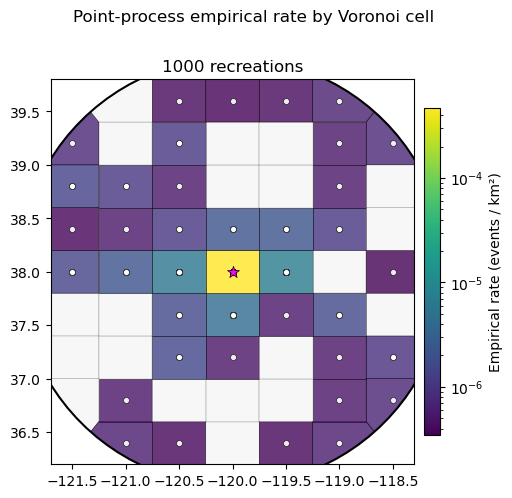

In [125]:
# Empirical rate per Voronoi cell from grid_recreations

if "_polygon_parts" not in globals():
    def _polygon_parts(geom):
        if geom.is_empty:
            return
        if geom.geom_type == "Polygon":
            yield geom
        elif geom.geom_type == "MultiPolygon":
            yield from geom.geoms
        elif geom.geom_type == "GeometryCollection":
            for g in geom.geoms:
                yield from _polygon_parts(g)

if "calculate_areas_km2" not in globals():
    def calculate_areas_km2(polygons):
        geod = pyproj.Geod(ellps="WGS84")
        areas = []
        for poly in polygons:
            if poly.is_empty:
                areas.append(0.0)
            else:
                area_m2, _ = geod.geometry_area_perimeter(poly)
                areas.append(abs(area_m2) / 1e6)
        return areas

if "cell_areas_km2" not in globals():
    cell_areas_km2 = np.array(calculate_areas_km2(ordered_cells), dtype=float)

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
xlim = (np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ylim = (np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)


def _bin_events_to_cells(pp_events):
    counts = np.zeros(len(ordered_cells), dtype=int)
    if "cell_idx" in pp_events.columns:
        for idx in pp_events["cell_idx"].astype(int).to_numpy():
            counts[idx] += 1
    else:
        for lon, lat in zip(pp_events["longitude"].to_numpy(), pp_events["latitude"].to_numpy()):
            j = int(np.argmin((lon_flat - lon) ** 2 + (lat_flat - lat) ** 2))
            counts[j] += 1
    return counts


def _counts_to_rate(counts, n_realizations):
    rate = np.zeros(len(ordered_cells), dtype=float)
    valid = cell_areas_km2 > 0
    rate[valid] = counts[valid] / (n_realizations * cell_areas_km2[valid])
    return rate


def _draw_rate_map(ax, pp_events, counts, rate, *, title):
    occupied = counts > 0
    if not occupied.any():
        ax.text(0.5, 0.5, "No events binned", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    plot_rate = np.maximum(rate, rate_vmin)
    for j, cell in enumerate(ordered_cells):
        if occupied[j]:
            facecolor = cmap(norm(plot_rate[j]))
            edge_lw = 0.4
            alpha = 0.8
        else:
            facecolor = "#f0f0f0"
            edge_lw = 0.2
            alpha = 0.5
        for part in _polygon_parts(cell):
            xy = np.asarray(part.exterior.coords)
            ax.add_patch(
                mpatches.Polygon(
                    xy,
                    closed=True,
                    facecolor=facecolor,
                    edgecolor="k",
                    alpha=alpha,
                    linewidth=edge_lw,
                )
            )

    ax.plot(lon_poly, lat_poly, color="black", linewidth=1.5)
    ax.scatter(
        pp_events["longitude"],
        pp_events["latitude"],
        s=18,
        c="white",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.9,
        zorder=7,
    )
    ax.scatter(
        [history_event_x],
        [history_event_y],
        s=80,
        c="magenta",
        marker="*",
        edgecolors="black",
        linewidths=0.5,
        zorder=8,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)


pp_events = grid_recreations
counts = _bin_events_to_cells(pp_events)
n_realizations_pp = len(pp_events)
rate_per_cell = _counts_to_rate(counts, n_realizations_pp)
positive = rate_per_cell[counts > 0]
if positive.size == 0:
    raise ValueError("No events were assigned to any Voronoi cell.")

rate_vmin = float(positive.min())
rate_vmax = float(positive.max())
if rate_vmin == rate_vmax:
    rate_vmax = rate_vmin * 10.0
norm = colors.LogNorm(vmin=rate_vmin, vmax=rate_vmax)
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(6, 5))
_draw_rate_map(
    ax,
    pp_events,
    counts,
    rate_per_cell,
    title=f"{n_realizations_pp} recreations",
)
print(
    f"binned {len(pp_events)} events; "
    f"non-zero cells {(counts > 0).sum()}/{len(ordered_cells)}; "
    f"max count {counts.max()}"
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Empirical rate (events / km²)")
fig.suptitle("Point-process empirical rate by Voronoi cell", y=1.02)
plt.show()


### Spatial rate comparison by Voronoi cell

Side-by-side maps at \(T_h\):

- **Classic ETAS (C)**: empirical density of first simulated event per recreation
- **Grid point process (B)**: empirical density from `grid_recreations`
- **Analytical (A)**: \(\lambda(x,y,t)=\mu + a_h(x,y)\,g(t)\) at each grid node / cell


2026-06-19 23:30:38,244 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7f101b3680d0>
2026-06-19 23:30:38,293 - DEBUG - vmin 3.437542808103896e-07 vmax 6.231144704527747
2026-06-19 23:30:38,294 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01,
       1.e+00, 1.e+01, 1.e+02])
2026-06-19 23:30:38,635 - DEBUG - vmin 3.437542808103896e-07 vmax 6.231144704527747
2026-06-19 23:30:38,635 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 

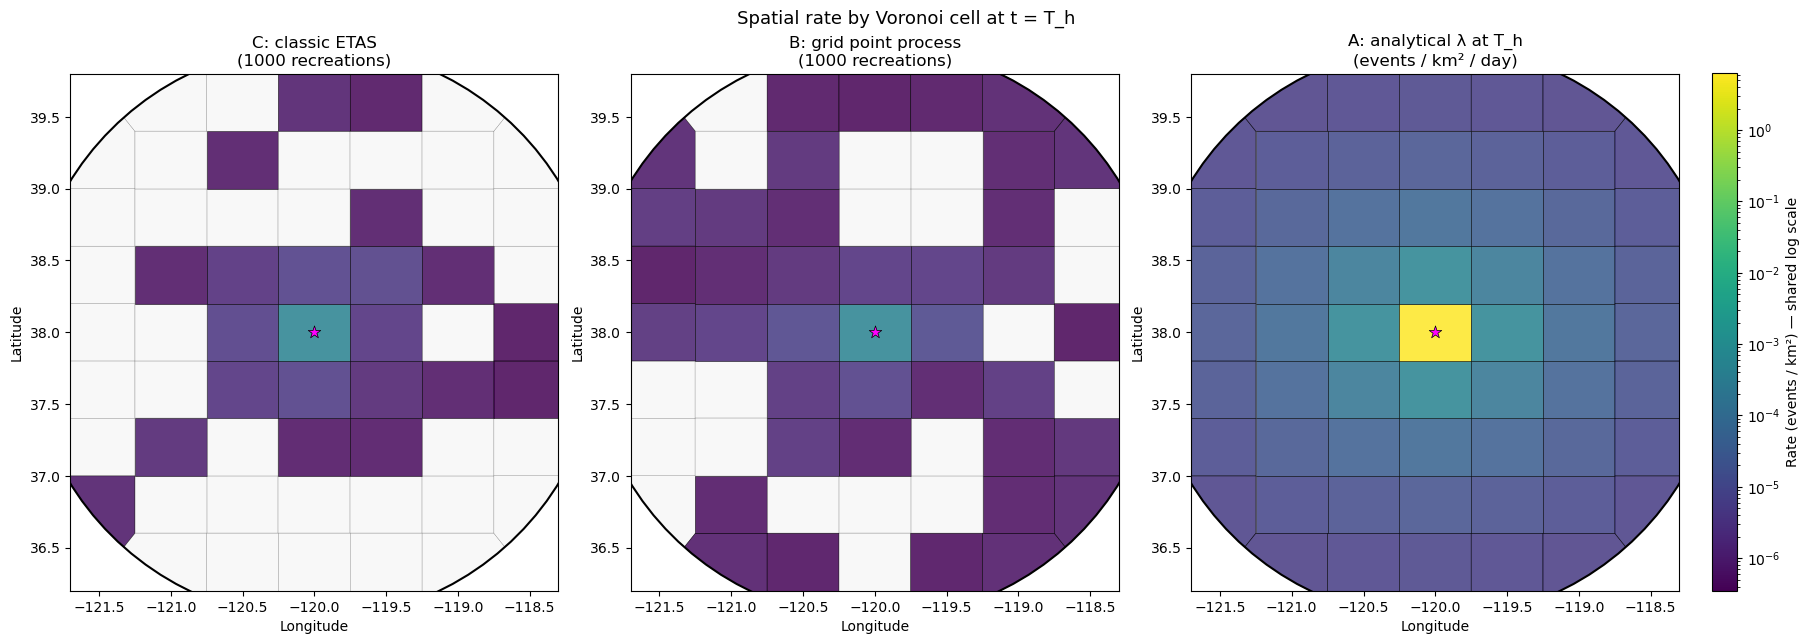

,method,n_recreations,nonzero_cells,max_rate
0,classic ETAS,1000.0,22,0.000480
1,grid point process,1000.0,39,0.000466
2,analytical,NaN,59,6.231145


In [126]:
# Side-by-side: classic sim vs grid PP vs analytical rate by Voronoi cell
if "_polygon_parts" not in globals():
    def _polygon_parts(geom):
        if geom.is_empty:
            return
        if geom.geom_type == "Polygon":
            yield geom
        elif geom.geom_type == "MultiPolygon":
            yield from geom.geoms
        elif geom.geom_type == "GeometryCollection":
            for g in geom.geoms:
                yield from _polygon_parts(g)

if "calculate_areas_km2" not in globals():
    def calculate_areas_km2(polygons):
        geod = pyproj.Geod(ellps="WGS84")
        areas = []
        for poly in polygons:
            if poly.is_empty:
                areas.append(0.0)
            else:
                area_m2, _ = geod.geometry_area_perimeter(poly)
                areas.append(abs(area_m2) / 1e6)
        return areas

if "cell_areas_km2" not in globals():
    cell_areas_km2 = np.array(calculate_areas_km2(ordered_cells), dtype=float)

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
xlim = (np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ylim = (np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)

history_t_days = float(history_dict["t"])
t_eval_rate = history_t_days


def _bin_lonlat_to_cells(lons, lats):
    counts = np.zeros(len(ordered_cells), dtype=int)
    for lon, lat in zip(np.asarray(lons, dtype=float), np.asarray(lats, dtype=float)):
        p = Point(lon, lat)
        for j, cell in enumerate(ordered_cells):
            if cell.contains(p):
                counts[j] += 1
                break
    return counts


def _empirical_rate_from_counts(counts, n_realizations):
    rate = np.zeros(len(ordered_cells), dtype=float)
    valid = cell_areas_km2 > 0
    rate[valid] = counts[valid] / (float(n_realizations) * cell_areas_km2[valid])
    return rate


# --- C: classic ETAS first-event locations ---
sim_events = (
    forecast_recreations.sort_values(["recreation", "time"])
    .groupby("recreation", as_index=False)
    .head(N_FORECAST_EVENTS)
)
sim_counts = _bin_lonlat_to_cells(
    sim_events["longitude"].to_numpy(), sim_events["latitude"].to_numpy()
)
n_sim = int(sim_events["recreation"].nunique())
sim_rate_per_cell = _empirical_rate_from_counts(sim_counts, n_sim)

# --- B: grid point-process recreations ---
pp_events = grid_recreations
if "cell_idx" in pp_events.columns:
    pp_counts = np.zeros(len(ordered_cells), dtype=int)
    for idx in pp_events["cell_idx"].astype(int).to_numpy():
        pp_counts[idx] += 1
else:
    pp_counts = _bin_lonlat_to_cells(
        pp_events["longitude"].to_numpy(), pp_events["latitude"].to_numpy()
    )
n_pp = len(pp_events)
pp_rate_per_cell = _empirical_rate_from_counts(pp_counts, n_pp)

# --- A: analytical intensity at grid nodes (one per Voronoi cell) ---
analytical_rate_per_cell = etas_rate_at_xy(
    lon_flat, lat_flat, t_eval_rate, history_dict, THETA_0
)
analytical_rate_per_cell = np.asarray(analytical_rate_per_cell, dtype=float)


def _draw_rate_panel(ax, rate_per_cell, *, title, counts=None):
    """Fill Voronoi cells with log-scaled rate; optional counts mask for empirical maps."""
    if counts is None:
        occupied = rate_per_cell > 0
    else:
        occupied = counts > 0

    plot_vals = np.maximum(rate_per_cell, rate_vmin)
    for j, cell in enumerate(ordered_cells):
        if occupied[j]:
            facecolor = cmap(norm(plot_vals[j]))
            alpha = 0.85
            lw = 0.4
        else:
            facecolor = "#f0f0f0"
            alpha = 0.45
            lw = 0.2
        for part in _polygon_parts(cell):
            xy = np.asarray(part.exterior.coords)
            ax.add_patch(
                mpatches.Polygon(
                    xy,
                    closed=True,
                    facecolor=facecolor,
                    edgecolor="k",
                    alpha=alpha,
                    linewidth=lw,
                )
            )

    ax.plot(lon_poly, lat_poly, color="black", linewidth=1.5)
    ax.scatter(
        [history_event_x],
        [history_event_y],
        s=90,
        c="magenta",
        marker="*",
        edgecolors="black",
        linewidths=0.5,
        zorder=8,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")


positive_all = np.concatenate(
    [
        sim_rate_per_cell[sim_rate_per_cell > 0],
        pp_rate_per_cell[pp_rate_per_cell > 0],
        analytical_rate_per_cell[analytical_rate_per_cell > 0],
    ]
)
if positive_all.size == 0:
    raise ValueError("All rate maps are zero; check upstream recreations.")
rate_vmin = float(positive_all.min())
rate_vmax = float(positive_all.max())
if rate_vmin == rate_vmax:
    rate_vmax = rate_vmin * 10.0
norm = colors.LogNorm(vmin=rate_vmin, vmax=rate_vmax)
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

_draw_rate_panel(
    axes[0],
    sim_rate_per_cell,
    title=f"C: classic ETAS\n({n_sim} recreations)",
    counts=sim_counts,
)
_draw_rate_panel(
    axes[1],
    pp_rate_per_cell,
    title=f"B: grid point process\n({n_pp} recreations)",
    counts=pp_counts,
)
_draw_rate_panel(
    axes[2],
    analytical_rate_per_cell,
    title=f"A: analytical λ at T_h\n(events / km² / day)",
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("Rate (events / km²) — shared log scale")

fig.suptitle(
    "Spatial rate by Voronoi cell at t = T_h",
    y=1.04,
    fontsize=13,
)
plt.show()

pd.DataFrame(
    {
        "method": ["classic ETAS", "grid point process", "analytical"],
        "n_recreations": [n_sim, n_pp, np.nan],
        "nonzero_cells": [
            int((sim_counts > 0).sum()),
            int((pp_counts > 0).sum()),
            int((analytical_rate_per_cell > 0).sum()),
        ],
        "max_rate": [
            float(sim_rate_per_cell.max()),
            float(pp_rate_per_cell.max()),
            float(analytical_rate_per_cell.max()),
        ],
    }
)


2026-06-19 23:30:39,667 - DEBUG - vmin 2.5686276785563678e-06 vmax 9.893738350924812
2026-06-19 23:30:39,667 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-19 23:30:39,678 - DEBUG - vmin 2.5686276785563678e-06 vmax 9.893738350924812
2026-06-19 23:30:39,678 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e

2026-06-19 23:30:39,894 - DEBUG - vmin 0.8 vmax 97.74999999999999
2026-06-19 23:30:39,895 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-19 23:30:39,896 - DEBUG - vmin 0.8 vmax 97.74999999999999
2026-06-19 23:30:39,896 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03])
2026-06-19 23:30:39,897 - DEBUG - vmin 0.8 vmax 97.74999999999999
2026-06-19 23:30:39,897 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-19 23:30:39,907 - DEBUG - vmin 0.8 vmax 97.74999999999999
2026-06-19 23:30:39,908 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.

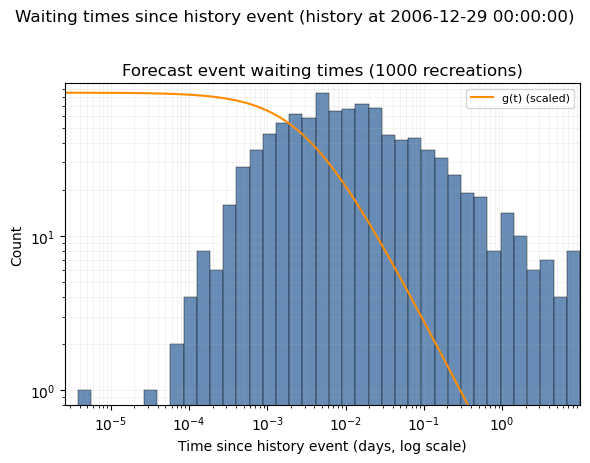

In [127]:
# Waiting-time histogram for grid point-process recreations
history_t_days = float(history_dict["t"])
delta_t_days = grid_recreations["time"].to_numpy() - history_t_days
positive = delta_t_days[delta_t_days > 0]
if positive.size == 0:
    raise ValueError("No positive waiting times to plot.")

xmax = max(1e-3, float(np.percentile(positive, 99.5)) * 1.1)
xmin = max(1e-6, float(np.min(positive)) * 0.5)
n_log_bins = 40
shared_bins = np.geomspace(xmin, xmax, n_log_bins)
t_plot = np.geomspace(xmin, xmax, 500)
g_vals = g(t_plot + history_t_days, history_dict, THETA_0)

counts, _ = np.histogram(positive, bins=shared_bins)
max_count = max(1, int(counts.max()))
g_scaled = g_vals * (max_count / max(g_vals.max(), 1e-30))
ymin = 0.8
ymax = max(max_count, float(g_scaled.max())) * 1.15

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    positive,
    bins=shared_bins,
    color="#4c78a8",
    edgecolor="black",
    linewidth=0.35,
    alpha=0.85,
)
ax.plot(
    t_plot,
    g_scaled,
    color="darkorange",
    linewidth=1.5,
    label="g(t) (scaled)",
)
ax.set_title(f"Forecast event waiting times ({len(delta_t_days)} recreations)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Time since history event (days, log scale)")
ax.set_ylabel("Count")
ax.grid(which="both", axis="both", alpha=0.25, linewidth=0.4)
ax.legend(loc="upper right", fontsize=8)
fig.suptitle(
    f"Waiting times since history event (history at {history_event_time})",
    y=1.02,
)
fig.tight_layout()
plt.show()


# Ogata's modified spatio-temporal thinning method 

In [128]:
from typing import Callable


def ogata_thinning_single_step(
    temporal_intensity: Callable[[float], float],
    t0: float,
    rng: np.random.RandomState,
) -> float:
    """
    Thinning method from Ogata (1981)
    Args:
        temporal_intensity: Callable[[float], float]
            Temporal intensity function. Argument is time.
        t0: float
            current time.
        rng: np.random.RandomState
            Random number generator.
    Returns:
    float: time of the next event.
    """
    # Get upper limit for the temporal intensity
    time = t0 + 0
    current_bound = temporal_intensity(time)
    
    while True:
        tau = rng.exponential(1.0 / current_bound)
        time += tau
        next_intensity = temporal_intensity(time) 
        u = rng.uniform()
        if u < (next_intensity / current_bound):
            return time
        current_bound = next_intensity    
    


In [129]:
def magnitude_generator():
    return mc_b_est.simulate_magnitudes(1, BETA_MAIN, THETA_0['m_c'])[0]


temporal_intensity = lambda t: etas_rate_space_integrated(t, np.pi*CIRC_RADIUS**2, CIRC_RADIUS, history_dict, THETA_0, A_H_RESOLUTION)

rngseed = 1905
rng = np.random.RandomState(rngseed)
T = ogata_thinning_single_step(temporal_intensity, history_dict['t'], rng)


In [130]:
def thinning_sample_location(
    spatiotemporal_rate: Callable[[float, float, float], float],
    estimation_t: float,
    rate_at_t: float,
    # rng: np.random.RandomState,
) -> float:
    """
    """
    return lambda x, y: spatiotemporal_rate(x, y, estimation_t) / rate_at_t

spatiotemporal_rate = lambda x, y, t: etas_rate_at_xy(x, y, t, history_dict, THETA_0)

P_x_y = thinning_sample_location(spatiotemporal_rate, T, temporal_intensity(T))


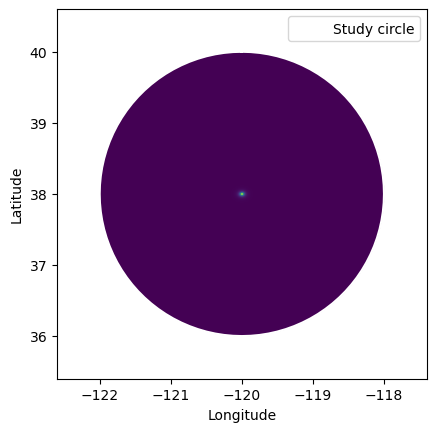

Integral of P_x_y over the circle: 9.637537902110074e-05


In [131]:
width_factor = 1.3
n_pix = 1000

# 1. Meshgrid (X=lon, Y=lat)
X, Y = np.meshgrid(
    np.linspace(
        history_dict["x"] - width_factor * CIRC_RADIUS,
        history_dict["x"] + width_factor * CIRC_RADIUS,
        n_pix,
    ),
    np.linspace(
        history_dict["y"] - width_factor * CIRC_RADIUS,
        history_dict["y"] + width_factor * CIRC_RADIUS,
        n_pix,
    ),
)
P_x_y_values = P_x_y(X, Y)

# Keep pixels only inside the circular study region
inside_circle = np.fromiter(
    (circle.contains(Point(lat, lon)) for lat, lon in zip(Y.ravel(), X.ravel())),
    dtype=bool,
    count=Y.size,
).reshape(Y.shape)
P_x_y_values = np.where(inside_circle, P_x_y_values, np.nan)

# 2. Plot extent
extent = [
    history_dict["x"] - width_factor * CIRC_RADIUS,
    history_dict["x"] + width_factor * CIRC_RADIUS,
    history_dict["y"] - width_factor * CIRC_RADIUS,
    history_dict["y"] + width_factor * CIRC_RADIUS,
]
fig, ax = plt.subplots()
ax.imshow(P_x_y_values, extent=extent, origin="lower", cmap="viridis")
circ_lats, circ_lons = circle.exterior.xy
ax.plot(circ_lons, circ_lats, color="white", linewidth=1.5, label="Study circle")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
# plt.colorbar()
ax.legend(loc="upper right")
plt.show()

# 3. Integrate only over in-circle pixels
dx = (2 * width_factor * CIRC_RADIUS) / (n_pix - 1)
dy = (2 * width_factor * CIRC_RADIUS) / (n_pix - 1)
P_x_y_integral = np.nansum(P_x_y_values) * dx * dy

print(f"Integral of P_x_y over the circle: {P_x_y_integral}")


In [132]:
times_thinning = []
rngseed = 1905
for i in range(N_RECREATIONS):
    rng = np.random.RandomState(rngseed)
    T = ogata_thinning_single_step(temporal_intensity, history_dict['t'], rng)
    times_thinning.append(T)
    rngseed += 1



2026-06-19 23:31:02,494 - DEBUG - vmin 0.7081944803829993 vmax 1402.157214587403
2026-06-19 23:31:02,495 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
2026-06-19 23:31:02,504 - DEBUG - vmin 0.7081944803829993 vmax 1402.157214587403
2026-06-19 23:31:02,504 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
2026-06-19 23:31:02,506 - DEBUG - vmin 0.7081944803829993 vmax 1402.157214587403
2026-06-19 23:31:02,506 - DEBU

2026-06-19 23:31:02,607 - DEBUG - vmin 0.7081944803829993 vmax 1402.157214587403
2026-06-19 23:31:02,608 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
2026-06-19 23:31:02,609 - DEBUG - vmin 0.7081944803829993 vmax 1402.157214587403
2026-06-19 23:31:02,609 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
2026-06-19 23:31:02,611 - DEBUG - vmin 0.7081944803829993 vmax 1402.157214587403
2026-06-19 23:31:02,611 - DEBU

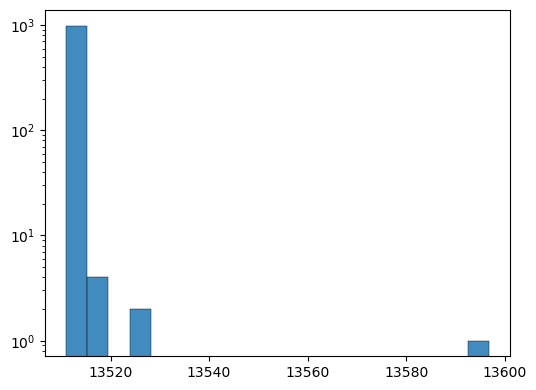

In [133]:
f, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(times_thinning, bins=20, edgecolor="black", linewidth=0.35, alpha=0.85)
ax.set_yscale("log")
plt.show()


# Apples-to-apples: three ways to forecast the first event

All three approaches target

\[
F(\Delta t) = P(\text{first event in California occurs by } T_h + \Delta t)
\]

where \(T_h\) is `history_event_time`. Plots use **CDF** \(F = 1 - S\), not survival `exp(log_rhs)`.

| Method | Implementation | Model |
|--------|----------------|-------|
| **A. Analytical** | `1 - exp(log_rhs)` | One parent event; \(\lambda=\mu + a_h(x,y)\,g(t)\); degree² `A_h`; no branching |
| **B. Grid point process** | `create_single_realization` → `min` over Voronoi cells | **Same model as A**; inverse transform per cell with random \(U_j\) |
| **C. Classic ETAS** | `simulate_catalog_continuation` | Production simulator: haversine km, discrete aftershocks, magnitude sampling |

### A vs B — should match

For B, the first event is \(T=\min_j T_j\) where each cell solves `log_rhs_j(T_j)=\log U_j`. Then

\[
P(T>\Delta t)=\prod_j \exp(\text{log\_rhs}_j)=\exp\Big(\sum_j \text{log\_rhs}_j\Big),
\qquad
F_B(\Delta t)=1-\exp\Big(\sum_j \text{log\_rhs}_j\Big).
\]

A single California integral `1 - exp(log_rhs)` is almost the same (partitioned `A_h` sums match), but the **exact** B counterpart is the product over cells. With enough Monte Carlo recreations, the B ECDF should sit on that curve (~median **0.03 days** here).

**If A and B looked far apart**, the usual cause is evaluating A on a **coarse linear** \(\Delta t\) grid (`linspace(0,100,400)` → first step \(\approx 0.25\) days) while most probability arrives before **0.05 days**. The next cell uses log-spaced \(\Delta t\) and interpolation for medians.

### C vs A/B — not just distance, not fixed by “first event only”

Keeping only the first simulated event removes later branching, but C still differs because:

- **Spatial kernel**: haversine **km** offsets (`simulate_aftershock_radius`) vs degree² integral `A_h`
- **Generative law**: Poisson **count** of aftershocks with random km locations vs continuous spatial intensity field
- **Background**: Poisson count + uniform times in window (first arrival still ~exponential, but combined with discrete aftershocks)
- **Area**: `polygon_surface` (projected km²) in simulation vs `Geod` + degree² distances in A/B

So C’s median (~**0.006 days**) can be faster than A/B (~**0.03 days**) even for the same parameters.


2026-06-19 23:31:02,847 - DEBUG - vmin 0.0001 vmax 486.80455044820405
2026-06-19 23:31:02,848 - DEBUG - ticklocs array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02,
       1.e+03, 1.e+04])
2026-06-19 23:31:02,859 - DEBUG - vmin 0.0001 vmax 486.80455044820405
2026-06-19 23:31:02,860 - DEBUG - ticklocs array([2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6

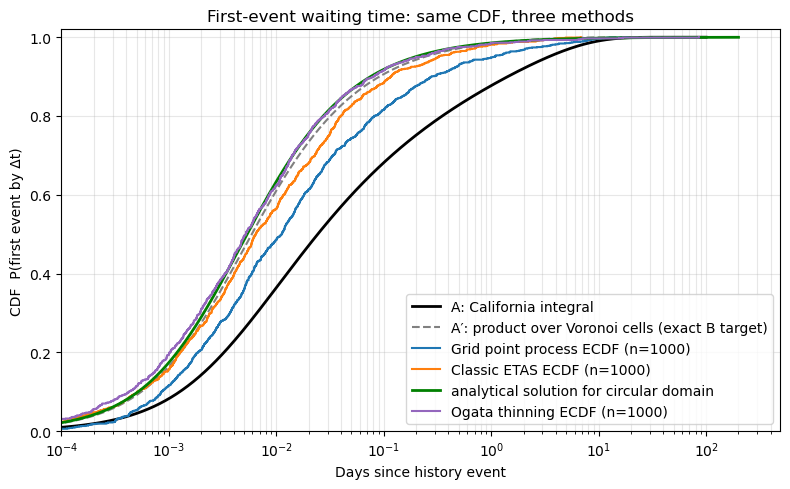

,method,n,median_days,p05_days,p95_days
0,A: California integral,400,0.024289,0.000563,3.404227
1,A′: product over cells,400,0.005898,0.000259,0.239387
2,B: grid point process,1000,0.011207,0.000465,1.038839
3,C: classic ETAS,1000,0.006429,0.000220,0.322347


In [134]:
def _ecdf_positive(samples):
    x = np.sort(np.asarray(samples, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return np.array([]), np.array([])
    return x, np.arange(1, x.size + 1, dtype=float) / x.size


def _analytical_median_dt(delta_t, cdf):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= 0.5):
        return np.nan
    return float(np.interp(0.5, cdf, delta_t))


def _analytical_quantile_dt(delta_t, cdf, q):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= q):
        return np.nan
    return float(np.interp(q, cdf, delta_t))


history_t_days = float(history_dict["t"])

# --- 1) Analytical CDFs (log-spaced Δt so the first ~0.01 days are resolved) ---
if "california_lonlat" not in globals():
    california_lonlat = transform(_swap_xy, polygon)

delta_t_analytical = np.geomspace(1e-5, 100.0, 400)
t_eval = delta_t_analytical + history_t_days

log_survival_ca = log_rhs(
    t_eval, history_t_days, california_lonlat, history_dict, THETA_0, A_H_RESOLUTION
)
cdf_ca = 1.0 - np.clip(np.exp(log_survival_ca), 0.0, 1.0)

# Exact B counterpart: product of per-cell survivals
log_survival_cells = np.zeros_like(delta_t_analytical, dtype=float)
for cell in ordered_cells:
    log_survival_cells += log_rhs(
        t_eval, history_t_days, cell, history_dict, THETA_0, A_H_RESOLUTION
    )
cdf_cells = 1.0 - np.clip(np.exp(log_survival_cells), 0.0, 1.0)


# --- 2) Grid point-process recreations (min over Voronoi cells) ---
delta_t_pp = grid_recreations["time"].to_numpy(dtype=float) - history_t_days
x_pp, y_pp = _ecdf_positive(delta_t_pp)

# --- 3) Classic ETAS catalog continuation ---
if "dt_to_first" not in globals():
    t0 = pd.to_datetime(FORECAST_START, utc=True)
    df_rec = forecast_recreations.loc[forecast_recreations["event_idx"] == 0].copy()
    df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
    dt_to_first = (
        df_rec.loc[df_rec["time"] > t0, "time"] - t0
    ).dt.total_seconds().to_numpy() / 86400.0
x_etas, y_etas = _ecdf_positive(dt_to_first)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    delta_t_analytical,
    cdf_ca,
    color="black",
    linewidth=2,
    label="A: California integral",
)
ax.plot(
    delta_t_analytical,
    cdf_cells,
    color="gray",
    linewidth=1.5,
    linestyle="--",
    label="A′: product over Voronoi cells (exact B target)",
)
if x_pp.size:
    ax.step(x_pp, y_pp, where="post", color="tab:blue", linewidth=1.5, label=f"Grid point process ECDF (n={x_pp.size})")
if x_etas.size:
    ax.step(x_etas, y_etas, where="post", color="tab:orange", linewidth=1.5, label=f"Classic ETAS ECDF (n={x_etas.size})")



# t_prime_analytical = np.linspace(0, 200, 1000)
t_prime_analytical = np.geomspace(1e-5, 200, 1000)
# P_no_event_before_t_prime = np.exp(log_t_next(t_prime_analytical, history_dict, THETA_0))
# cdf = 1 - P_no_event_before_t_prime
S_vec_circular = np.exp(
    log_rhs_region(t_prime_analytical + history_dict['t'], history_dict['t'], history_dict, THETA_0, resolution=A_H_RESOLUTION)
)
# Convert survival probability to CDF
cdf_circ_analytical = 1.0 - S_vec_circular
ax.plot(t_prime_analytical, cdf_circ_analytical, color="green", linewidth=2, label="analytical solution for circular domain")


delta_t_thinning = np.array(times_thinning) - history_t_days
x_thinning, y_thinning = _ecdf_positive(delta_t_thinning)
ax.step(x_thinning, y_thinning, where="post", color="tab:purple", linewidth=1.5, label=f"Ogata thinning ECDF (n={x_thinning.size})")



ax.set_xscale("log")
ax.set_xlim(left=max(1e-4, np.min([delta_t_analytical[1], x_pp.min() if x_pp.size else 1e-3, x_etas.min() if x_etas.size else 1e-3]) * 0.5))
ax.set_ylim(0, 1.02)
ax.set_xlabel("Days since history event")
ax.set_ylabel("CDF  P(first event by Δt)")
ax.set_title("First-event waiting time: same CDF, three methods")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Summary stats for quick numeric comparison
def _quantile_row(name, x):
    if x.size == 0:
        return {"method": name, "n": 0}
    q = np.quantile(x, [0.05, 0.5, 0.95])
    return {
        "method": name,
        "n": int(x.size),
        "median_days": float(q[1]),
        "p05_days": float(q[0]),
        "p95_days": float(q[2]),
    }


summary = pd.DataFrame(
    [
        {
            "method": "A: California integral",
            "n": int(delta_t_analytical.size),
            "median_days": _analytical_median_dt(delta_t_analytical, cdf_ca),
            "p05_days": _analytical_quantile_dt(delta_t_analytical, cdf_ca, 0.05),
            "p95_days": _analytical_quantile_dt(delta_t_analytical, cdf_ca, 0.95),
        },
        {
            "method": "A′: product over cells",
            "n": int(delta_t_analytical.size),
            "median_days": _analytical_median_dt(delta_t_analytical, cdf_cells),
            "p05_days": _analytical_quantile_dt(delta_t_analytical, cdf_cells, 0.05),
            "p95_days": _analytical_quantile_dt(delta_t_analytical, cdf_cells, 0.95),
        },
        _quantile_row("B: grid point process", delta_t_pp[delta_t_pp > 0]),
        _quantile_row("C: classic ETAS", dt_to_first[dt_to_first > 0]),
    ]
)
summary


### PDF check: histograms vs analytical \(dF/d\Delta t\)

If B (and approximately C for the simplified model) is consistent with the analytical compensator, normalized histograms of \(\Delta t\) should follow the PDF obtained by differentiating the analytical CDF (here: **A′**, product over Voronoi cells).


2026-06-19 23:31:03,428 - DEBUG - vmin 1.8771860995370372e-06 vmax 7.887784870848862
2026-06-19 23:31:03,428 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-19 23:31:03,439 - DEBUG - vmin 1.8771860995370372e-06 vmax 7.887784870848862
2026-06-19 23:31:03,440 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e

2026-06-19 23:31:03,533 - DEBUG - vmin 1.8771860995370372e-06 vmax 7.887784870848862
2026-06-19 23:31:03,534 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-19 23:31:03,535 - DEBUG - vmin 1.8771860995370372e-06 vmax 7.887784870848862
2026-06-19 23:31:03,536 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e

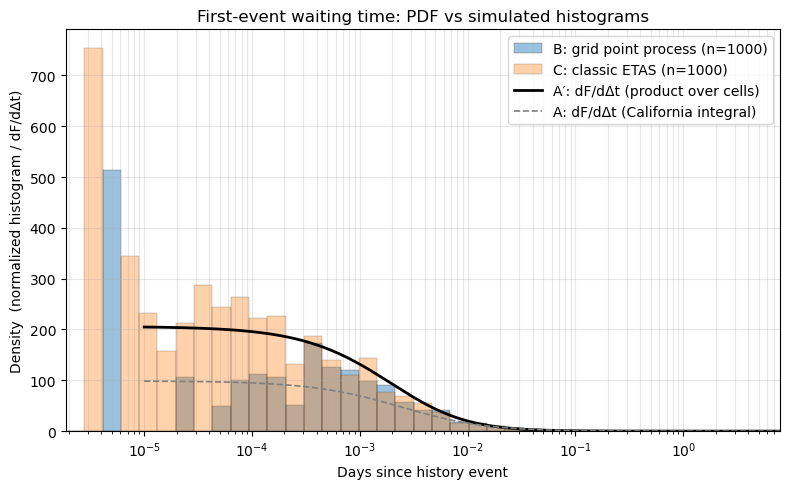

In [135]:
# Requires the previous comparison cell (delta_t_analytical, cdf_cells, delta_t_pp, dt_to_first).
pdf_cells = np.gradient(cdf_cells, delta_t_analytical)
pdf_cells = np.clip(pdf_cells, 0.0, None)

pdf_ca = np.clip(np.gradient(cdf_ca, delta_t_analytical), 0.0, None)

samples_for_bins = []
if "delta_t_pp" in globals():
    samples_for_bins.append(np.asarray(delta_t_pp, dtype=float))
if "dt_to_first" in globals():
    samples_for_bins.append(np.asarray(dt_to_first, dtype=float))
positive_all = np.concatenate(
    [x[(x > 0) & np.isfinite(x)] for x in samples_for_bins if x.size]
) if samples_for_bins else np.array([])
if positive_all.size == 0:
    raise ValueError("Run grid recreations and/or catalog continuation first.")

xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
xmax = max(xmin * 10, float(np.percentile(positive_all, 99.5)) * 1.1)
hist_bins = np.geomspace(xmin, xmax, 40)

fig, ax = plt.subplots(figsize=(8, 5))

delta_t_pos = delta_t_pp[(delta_t_pp > 0) & np.isfinite(delta_t_pp)]
if delta_t_pos.size:
    ax.hist(
        delta_t_pos,
        bins=hist_bins,
        density=True,
        alpha=0.45,
        color="tab:blue",
        edgecolor="black",
        linewidth=0.35,
        label=f"B: grid point process (n={delta_t_pos.size})",
    )

dt_pos = dt_to_first[(dt_to_first > 0) & np.isfinite(dt_to_first)]
if dt_pos.size:
    ax.hist(
        dt_pos,
        bins=hist_bins,
        density=True,
        alpha=0.35,
        color="tab:orange",
        edgecolor="black",
        linewidth=0.35,
        label=f"C: classic ETAS (n={dt_pos.size})",
    )

mask_pdf = (delta_t_analytical >= xmin) & (delta_t_analytical <= xmax) & np.isfinite(pdf_cells)
ax.plot(
    delta_t_analytical[mask_pdf],
    pdf_cells[mask_pdf],
    color="black",
    linewidth=2.0,
    label="A′: dF/dΔt (product over cells)",
)
ax.plot(
    delta_t_analytical[mask_pdf],
    pdf_ca[mask_pdf],
    color="gray",
    linewidth=1.2,
    linestyle="--",
    label="A: dF/dΔt (California integral)",
)



ax.set_xscale("log")
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Days since history event")
ax.set_ylabel("Density  (normalized histogram / dF/dΔt)")
ax.set_title("First-event waiting time: PDF vs simulated histograms")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


Text(0.5, 1.0, 'CDF of time to first event')

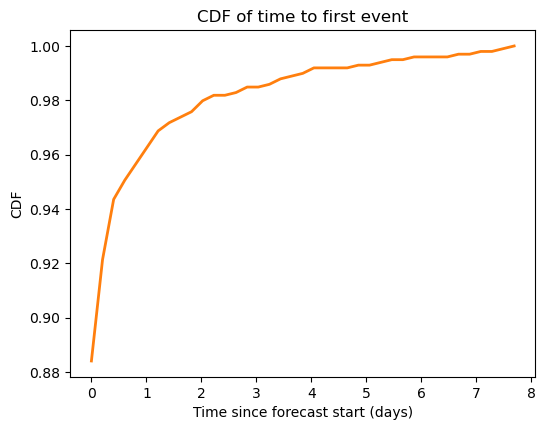

In [136]:

# shared_bins

# xmax = max(1e-3, float(np.percentile(positive_all, 99.5)) * 1.1)
# xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
# n_log_bins = 40


shared_bins_linear = np.linspace(
        xmin,
        xmax,
        n_log_bins,
    )
    
hist, bins = np.histogram(
    positive,
    bins=shared_bins_linear,
)

# CDF
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

fig_cdf, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(bins[:-1], cdf, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("CDF")
ax.set_title("CDF of time to first event")
